In [53]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import gseapy as gp



In [54]:
file_path_manual = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS"
gsea_df_go = pd.read_csv(f'{file_path_manual}/pathway_go_dys_analysis_170drugs.csv', index_col = 0) 

In [55]:
gsea_df_go.columns

Index(['Term', 'ES', 'NES', 'FDR', 'drug'], dtype='object')

In [56]:
gsea_df_go.shape

(390320, 5)

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import skfuzzy as fuzz

In [58]:
import re

def clean_go_term(term, shorten=True, sentence_case=True):
    """
    Clean GO term names:
    1) remove GO ID if present
    2) replace underscores with spaces
    3) convert uppercase to sentence case
    4) optionally shorten common long phrases
    """
    term = str(term)

    # 去掉类似 " (GO:0001234)"
    term = re.sub(r"\s*\(GO:\d+\)", "", term)

    # 下划线改空格
    term = term.replace("_", " ")

    # 多余空格
    term = re.sub(r"\s+", " ", term).strip()

    if shorten:
        replacements = {
            "positive regulation of": "pos. reg. of",
            "negative regulation of": "neg. reg. of",
            "regulation of": "reg. of",
            "cellular response to": "response to",
            "signaling pathway": "signaling",
            "biosynthetic process": "biosynthesis",
            "metabolic process": "metabolism",
            "catabolic process": "catabolism",
            "homeostatic process": "homeostasis",
            "cell proliferation": "proliferation",
            "apoptotic process": "apoptosis",
            "inflammatory response": "inflammation",
            "immune system process": "immune process",
            "response to": "resp. to",
            "process": ""
        }

        # 小写后替换，最后再决定大小写
        lower_term = term.lower()
        for old, new in replacements.items():
            lower_term = lower_term.replace(old, new)

        term = re.sub(r"\s+", " ", lower_term).strip()

    # 改成只有首字母大写
    if sentence_case:
        term = term[:1].upper() + term[1:].lower() if term else term

    return term

In [59]:
def run_fcm_on_gsea(
    gsea_df_go,
    fdr_thresh=0.05,
    nes_fill_value=0,
    min_drugs_per_term=3,
    top_var_terms=None,
    n_clusters=6,
    fuzziness=1.5,
    pca_components=None,
    random_state=0
):
    """
    Run Fuzzy C-means clustering on GO GSEA results.

    Parameters
    ----------
    gsea_df_go : pd.DataFrame
        Must contain columns: ['Term', 'ES', 'NES', 'FDR', 'drug']
    fdr_thresh : float
        Keep rows with FDR <= this threshold
    nes_fill_value : float
        Value used to fill missing drug-term NES entries after pivot
    min_drugs_per_term : int
        Keep GO terms that are significant in at least this many drugs
    top_var_terms : int or None
        If not None, keep only top N most variable GO terms across drugs
    n_clusters : int
        Number of fuzzy clusters
    fuzziness : float
        FCM parameter m, usually between 1.3 and 2.0
    pca_components : int or None
        If not None, reduce dimensions before FCM
    random_state : int
        Random seed for reproducibility

    Returns
    -------
    result : dict
        {
            "filtered_df": ...,
            "nes_matrix": ...,
            "scaled_matrix": ...,
            "matrix_for_fcm": ...,
            "membership": ...,
            "cluster_profile": ...,
            "fpc": ...
        }
    """
    np.random.seed(random_state)

    # ----------------------------
    # 1. basic check
    # ----------------------------
    required_cols = {"Term", "ES", "NES", "FDR", "drug"}
    missing_cols = required_cols - set(gsea_df_go.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    df = gsea_df_go.copy()

    # ----------------------------
    # 2. FDR filtering
    # ----------------------------
    df = df[df["FDR"] <= fdr_thresh].copy()

    if df.empty:
        raise ValueError("No rows left after FDR filtering. Try a larger fdr_thresh.")

    # ----------------------------
    # 3. keep terms appearing in at least X drugs
    # ----------------------------
    term_counts = df.groupby("Term")["drug"].nunique()
    keep_terms = term_counts[term_counts >= min_drugs_per_term].index

    df = df[df["Term"].isin(keep_terms)].copy()

    if df.empty:
        raise ValueError("No rows left after min_drugs_per_term filtering. Lower this threshold.")

    # ----------------------------
    # 4. pivot to drug × term NES matrix
    # ----------------------------
    nes_matrix = df.pivot_table(
        index="drug",
        columns="Term",
        values="NES",
        aggfunc="mean"
    )

    # fill missing values
    nes_matrix = nes_matrix.fillna(nes_fill_value)

    # ----------------------------
    # 5. optionally keep top variable terms
    # ----------------------------
    if top_var_terms is not None:
        if top_var_terms <= 0:
            raise ValueError("top_var_terms must be a positive integer or None.")
        term_var = nes_matrix.var(axis=0).sort_values(ascending=False)
        keep_top = term_var.head(top_var_terms).index
        nes_matrix = nes_matrix[keep_top].copy()

    if nes_matrix.shape[1] < 2:
        raise ValueError("Too few GO terms remain for clustering.")

    # ----------------------------
    # 6. scale matrix
    #    row = drug, col = term
    # ----------------------------
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(nes_matrix)

    scaled_matrix = pd.DataFrame(
        scaled_values,
        index=nes_matrix.index,
        columns=nes_matrix.columns
    )

    # ----------------------------
    # 7. optional PCA
    # ----------------------------
    matrix_for_fcm = scaled_matrix.copy()

    if pca_components is not None:
        max_pc = min(scaled_matrix.shape[0], scaled_matrix.shape[1])
        if pca_components > max_pc:
            raise ValueError(f"pca_components cannot exceed {max_pc}")

        pca = PCA(n_components=pca_components, random_state=random_state)
        pca_values = pca.fit_transform(scaled_matrix)

        matrix_for_fcm = pd.DataFrame(
            pca_values,
            index=scaled_matrix.index,
            columns=[f"PC{i+1}" for i in range(pca_values.shape[1])]
        )

    # ----------------------------
    # 8. FCM clustering
    #    skfuzzy expects shape = features × samples
    # ----------------------------
    data_for_fcm = matrix_for_fcm.T.values

    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data=data_for_fcm,
        c=n_clusters,
        m=fuzziness,
        error=1e-5,
        maxiter=1000,
        init=None
    )

    # u shape = (n_clusters, n_samples)
    membership = pd.DataFrame(
        u.T,
        index=matrix_for_fcm.index,
        columns=[f"cluster_{i+1}" for i in range(n_clusters)]
    )

    # main cluster
    membership["main_cluster"] = membership.idxmax(axis=1)

    # max membership
    membership["max_membership"] = membership[[f"cluster_{i+1}" for i in range(n_clusters)]].max(axis=1)

    # entropy-like measure (higher = more mixed)
    cluster_cols = [f"cluster_{i+1}" for i in range(n_clusters)]
    membership["membership_entropy"] = -np.sum(
        membership[cluster_cols].values * np.log(membership[cluster_cols].values + 1e-12),
        axis=1
    )

    # ----------------------------
    # 9. cluster-level pathway profile
    #    use main_cluster for summary
    # ----------------------------
    cluster_profile = (
        nes_matrix.join(membership["main_cluster"])
        .groupby("main_cluster")
        .mean()
    )

    return {
        "filtered_df": df,
        "nes_matrix": nes_matrix,
        "scaled_matrix": scaled_matrix,
        "matrix_for_fcm": matrix_for_fcm,
        "membership": membership,
        "cluster_profile": cluster_profile,
        "fpc": fpc
    }

In [60]:
result = run_fcm_on_gsea(
    gsea_df_go=gsea_df_go,
    fdr_thresh=0.05,
    nes_fill_value=0,
    min_drugs_per_term=3,
    top_var_terms=200,     # 如果term太多，先保留最有变化的300个
    n_clusters=10,
    fuzziness=1.7,
    pca_components=20,     # GO term很多时推荐加PCA
    random_state=0
)

In [61]:
filtered_df = result["filtered_df"]
filtered_df

,Term,ES,NES,FDR,drug
0,REGULATION_OF_MITOTIC_NUCLEAR_DIVISION,-0.710265,-2.377711,0.000000,6-Mercaptopurine
1,REGULATION_OF_NUCLEAR_DIVISION,-0.703381,-2.369761,0.000000,6-Mercaptopurine
2,MITOTIC_SISTER_CHROMATID_SEPARATION,-0.711844,-2.357902,0.000000,6-Mercaptopurine
3,REGULATION_OF_MITOTIC_SISTER_CHROMATID_SEGREGA...,-0.717321,-2.292561,0.000000,6-Mercaptopurine
4,NEGATIVE_REGULATION_OF_NUCLEAR_DIVISION,-0.730533,-2.278584,0.000000,6-Mercaptopurine
...,...,...,...,...,...
385750,LIPID_MODIFICATION,0.517503,1.881719,0.039913,Î±-Lipoic Acid
385751,MAMMARY_GLAND_MORPHOGENESIS,0.756726,1.878035,0.040087,Î±-Lipoic Acid
385752,MONOCARBOXYLIC_ACID_TRANSPORT,0.558381,1.877859,0.037415,Î±-Lipoic Acid
385754,SMOOTH_MUSCLE_CELL_MIGRATION,0.650465,1.854431,0.046989,Î±-Lipoic Acid


In [62]:
nes_matrix = result["nes_matrix"]
nes_matrix

Term,INTERMEDIATE_FILAMENT_ORGANIZATION,INTERMEDIATE_FILAMENT_BASED_PROCESS,KERATINOCYTE_DIFFERENTIATION,RNA_SPLICING,RIBOSOMAL_SMALL_SUBUNIT_BIOGENESIS,RRNA_PROCESSING,RNA_SPLICING_VIA_TRANSESTERIFICATION_REACTIONS,RIBONUCLEOPROTEIN_COMPLEX_BIOGENESIS,RIBOSOME_BIOGENESIS,MATURATION_OF_SSU_RRNA,...,NEGATIVE_REGULATION_OF_CELL_CYCLE_G2_M_PHASE_TRANSITION,PROTEIN_CATABOLIC_PROCESS_IN_THE_VACUOLE,REGULATION_OF_CELL_DIVISION,PROTEIN_RNA_COMPLEX_ORGANIZATION,REGULATION_OF_DNA_TEMPLATED_DNA_REPLICATION,CENTRIOLE_ASSEMBLY,MATURATION_OF_SSU_RRNA_FROM_TRICISTRONIC_RRNA_TRANSCRIPT_SSU_RRNA_5_8S_RRNA_LSU_RRNA,ISOPRENOID_BIOSYNTHETIC_PROCESS,NEURON_PROJECTION_GUIDANCE,POSITIVE_REGULATION_OF_MITOTIC_NUCLEAR_DIVISION
drug,,,,,,,,,,,,,,,,,,,,,
6-Mercaptopurine,0.000000,0.000000,1.807077,0.000000,-1.874859,-1.730007,0.000000,-1.760954,-1.935513,-1.739768,...,0.000000,0.00000,-1.725892,0.000000,-1.783409,-1.919639,0.000000,0.000000,1.820281,-1.863857
ATP (dimagnesium),-1.810522,0.000000,0.000000,0.000000,0.000000,-1.854691,0.000000,-1.895123,-1.909979,-1.822942,...,0.000000,0.00000,0.000000,0.000000,-1.895197,0.000000,0.000000,0.000000,0.000000,0.000000
Abemaciclib (methanesulfonate),0.000000,0.000000,1.797888,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.678335,0.00000,-1.637027,0.000000,-1.863315,-1.651100,0.000000,0.000000,0.000000,-1.589931
Acetophenazine (dimaleate),-2.444746,-2.614464,-2.275356,-2.092508,-2.295920,-2.273547,-2.036551,-2.127150,-2.046297,-2.269147,...,0.000000,1.79848,0.000000,-1.842546,0.000000,0.000000,-1.741255,1.814091,1.946372,0.000000
Adiphenine (hydrochloride),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Varenicline (Hydrochloride),-2.486422,-2.311460,0.000000,-2.002691,0.000000,0.000000,-2.017334,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Vasopressin,-2.397502,-2.234492,0.000000,-1.987142,0.000000,0.000000,-1.940299,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Vemurafenib,-2.160315,-1.979381,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [63]:
[item for item in nes_matrix.index if "Chlorpropamide" in item]

['Chlorpropamide']

In [64]:
# nes_matrix

file_path_go = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\GOGESA"
# nes_matrix.to_csv(f'{file_path_go}/pathway_go_nesmatrix_159drugs_top200.csv') 

In [65]:
membership_df = result["membership"]
membership_df

,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10,main_cluster,max_membership,membership_entropy
drug,,,,,,,,,,,,,
6-Mercaptopurine,0.465420,0.037318,0.136738,0.040778,0.036918,0.035636,0.064769,0.039371,0.074885,0.068167,cluster_1,0.465420,1.803623
ATP (dimagnesium),0.001674,0.138089,0.001195,0.003292,0.429627,0.026126,0.000577,0.367270,0.000875,0.031276,cluster_5,0.429627,1.255856
Abemaciclib (methanesulfonate),0.715480,0.023161,0.059602,0.022287,0.025179,0.021190,0.030076,0.026007,0.030339,0.046680,cluster_1,0.715480,1.203370
Acetophenazine (dimaleate),0.025692,0.042158,0.039043,0.526033,0.033800,0.054138,0.046373,0.040781,0.123119,0.068862,cluster_4,0.526033,1.679499
Adiphenine (hydrochloride),0.000522,0.016987,0.000359,0.000973,0.896311,0.005451,0.000176,0.070017,0.000263,0.008941,cluster_5,0.896311,0.441337
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Varenicline (Hydrochloride),0.000899,0.086376,0.000637,0.001911,0.239810,0.016018,0.000321,0.636570,0.000491,0.016967,cluster_8,0.636570,1.006142
Vasopressin,0.001296,0.120147,0.000926,0.002930,0.182639,0.025230,0.000472,0.640852,0.000729,0.024778,cluster_8,0.640852,1.075799
Vemurafenib,0.071192,0.105375,0.033657,0.072250,0.131883,0.085165,0.020364,0.135336,0.033113,0.311665,cluster_10,0.311665,2.032337


In [66]:
# membership_df.to_csv(f'{file_path_go}/pathway_go_membership_159drugs_10clusters.csv') 

In [99]:
membership_df["main_cluster"].value_counts()

main_cluster
cluster_5     55
cluster_2     29
cluster_6     16
cluster_8     12
cluster_1     11
cluster_4      8
cluster_9      7
cluster_7      7
cluster_3      7
cluster_10     7
Name: count, dtype: int64

In [68]:
cluster_profile = result["cluster_profile"]
cluster_profile

,INTERMEDIATE_FILAMENT_ORGANIZATION,INTERMEDIATE_FILAMENT_BASED_PROCESS,KERATINOCYTE_DIFFERENTIATION,RNA_SPLICING,RIBOSOMAL_SMALL_SUBUNIT_BIOGENESIS,RRNA_PROCESSING,RNA_SPLICING_VIA_TRANSESTERIFICATION_REACTIONS,RIBONUCLEOPROTEIN_COMPLEX_BIOGENESIS,RIBOSOME_BIOGENESIS,MATURATION_OF_SSU_RRNA,...,NEGATIVE_REGULATION_OF_CELL_CYCLE_G2_M_PHASE_TRANSITION,PROTEIN_CATABOLIC_PROCESS_IN_THE_VACUOLE,REGULATION_OF_CELL_DIVISION,PROTEIN_RNA_COMPLEX_ORGANIZATION,REGULATION_OF_DNA_TEMPLATED_DNA_REPLICATION,CENTRIOLE_ASSEMBLY,MATURATION_OF_SSU_RRNA_FROM_TRICISTRONIC_RRNA_TRANSCRIPT_SSU_RRNA_5_8S_RRNA_LSU_RRNA,ISOPRENOID_BIOSYNTHETIC_PROCESS,NEURON_PROJECTION_GUIDANCE,POSITIVE_REGULATION_OF_MITOTIC_NUCLEAR_DIVISION
main_cluster,,,,,,,,,,,,,,,,,,,,,
cluster_1,1.101545,0.818506,1.807565,-0.166737,-0.170442,-0.157273,-0.168553,-0.316516,-0.327286,-0.158161,...,-1.105456,0.175162,-1.655613,0.000000,-1.648330,-1.641432,0.000000,0.006929,0.331653,-1.205981
cluster_10,1.276148,1.131810,1.809797,0.000000,-0.255588,-0.257333,0.000000,-0.274985,-0.278202,0.000000,...,-0.470366,0.253417,0.000000,0.000000,-0.473492,-0.737953,-0.237570,0.273632,0.000000,0.000000
cluster_2,-1.323045,-1.021809,-0.269685,-2.086230,-1.931091,-1.861518,-1.984058,-1.788879,-1.654551,-1.854356,...,-0.062045,0.000000,0.000000,-0.064539,0.000000,0.000000,0.000000,0.069265,0.000000,0.000000
cluster_3,0.380229,0.364705,0.343923,-0.585581,-1.469933,-1.745211,-0.564374,-1.475612,-1.765243,-1.370130,...,-1.561900,0.561970,-1.485186,-0.500131,-1.048705,-0.860751,-0.518620,1.367221,0.252178,-1.876486
cluster_4,-1.835503,-1.779251,-0.734541,-2.105607,-2.108444,-2.056919,-2.050446,-1.827511,-1.777857,-2.003100,...,0.000000,1.366260,0.000000,-0.454932,0.000000,0.000000,-0.677007,0.936838,1.204106,-0.226027
cluster_5,-0.937574,-0.772287,-0.015438,-0.141331,0.000000,-0.103297,-0.036707,-0.034457,-0.070254,-0.067785,...,0.000000,0.000000,0.000000,0.000000,-0.034458,0.000000,0.000000,0.000000,0.000000,0.000000
cluster_6,-1.049882,-0.893723,-0.357148,-2.246557,-2.175276,-2.090668,-2.208251,-2.172637,-2.036147,-2.129270,...,0.000000,0.110814,0.000000,-0.850949,0.000000,0.000000,-1.059771,0.123948,0.353477,0.000000
cluster_7,-0.905385,-0.837376,0.000000,-1.119887,-1.490410,-1.401687,-1.128079,-1.700709,-1.680897,-1.123298,...,-1.939789,1.894806,-1.977819,-1.238723,-1.820046,-1.835704,-0.827887,0.537970,1.536936,-1.904628
cluster_8,-1.321031,-0.945935,-0.124515,-2.013796,-0.161481,-0.323690,-1.991135,-0.304989,0.000000,-0.310844,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.167060,0.000000,0.000000


In [192]:
top_up_terms = {}
top_down_terms = {}

for cl in cluster_profile.index:
    s = cluster_profile.loc[cl].sort_values(ascending=False)
    top_up_terms[cl] = s.head(10)
    top_down_terms[cl] = s.tail(10)

for cl in top_up_terms:
    print(f"\n===== {cl} : Top Up Terms =====")
    print(top_up_terms[cl])
    
    print(f"\n===== {cl} : Top Down Terms =====")
    print(top_down_terms[cl])


===== cluster_1 : Top Up Terms =====
KERATINOCYTE_DIFFERENTIATION                          1.890961
AMINO_ACID_IMPORT_ACROSS_PLASMA_MEMBRANE              1.816614
EPIDERMAL_CELL_DIFFERENTIATION                        1.492840
INTERMEDIATE_FILAMENT_ORGANIZATION                    1.452505
ORGANIC_ANION_TRANSPORT                               1.169780
INTERMEDIATE_FILAMENT_BASED_PROCESS                   1.097051
LIPID_HOMEOSTASIS                                     1.079315
ORGANIC_ACID_TRANSPORT                                0.984077
TISSUE_REMODELING                                     0.863143
CELLULAR_RESPONSE_TO_LIPOPROTEIN_PARTICLE_STIMULUS    0.814463
Name: cluster_1, dtype: float64

===== cluster_1 : Top Down Terms =====
MEIOTIC_CELL_CYCLE_PROCESS                           -2.099645
POSITIVE_REGULATION_OF_CELL_CYCLE_PROCESS            -2.102183
CHROMOSOME_SEPARATION                                -2.110082
REGULATION_OF_SISTER_CHROMATID_SEGREGATION           -2.134274
MEIOSIS_

In [235]:
cluster_cols = [c for c in membership_df.columns if c.startswith("cluster_")]

representative_drugs = []

for cl in cluster_cols:
    sub = membership_df.sort_values(cl, ascending=False).head(10).copy()
    sub = sub[[cl, "main_cluster", "max_membership", "membership_entropy"]]
    sub["representing_cluster"] = cl
    sub["drug"] = sub.index
    representative_drugs.append(sub.reset_index(drop=True))

representative_drugs_df = pd.concat(representative_drugs, ignore_index=True)
representative_drugs_df

,cluster_1,main_cluster,max_membership,membership_entropy,representing_cluster,drug,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10
0,0.894274,cluster_1,0.894274,0.537283,cluster_1,Etravirine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.892511,cluster_1,0.892511,0.551070,cluster_1,Remdesivir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.843542,cluster_1,0.843542,0.724261,cluster_1,Olmutinib,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.808980,cluster_1,0.808980,0.828819,cluster_1,Neratinib,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.806417,cluster_1,0.806417,0.845503,cluster_1,Abemaciclib (methanesulfonate),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,NaN,cluster_10,0.744280,0.980722,cluster_10,Stiripentol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.744280
96,NaN,cluster_10,0.667162,1.118048,cluster_10,Vardenafil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.667162
97,NaN,cluster_10,0.639818,1.219153,cluster_10,Chloropyramine hydrochloride,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.639818
98,NaN,cluster_10,0.587689,1.218599,cluster_10,Betamethasone valerate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.587689


# plot PCA and UMAP for clustering results 

In [116]:
outdir3 = r"C:\Users\jymbc\Desktop\drug_portal\data\drug_clustering_results"

In [117]:
drug_clustering_go_fcm_matrix = pd.read_csv(f'{outdir3}/drug_clustering_go_fcm_matrix.csv') 

drug_clustering_go_fcm_membership = pd.read_csv(f'{outdir3}/drug_clustering_go_fcm_membership.csv') 

drug_clustering_go_fcm_summary = pd.read_csv(f'{outdir3}/drug_clustering_go_fcm_summary.csv') 

In [122]:
membership_df_go = drug_clustering_go_fcm_membership[["drug", "main_cluster"]]

In [131]:
df_plot = drug_clustering_go_fcm_matrix.copy()

df_plot  = df_plot.iloc[:, [0, 2] + list(range(8, df_plot.shape[1]))]
df_plot 

,drug,cluster,INTERMEDIATE_FILAMENT_ORGANIZATION,INTERMEDIATE_FILAMENT_BASED_PROCESS,KERATINOCYTE_DIFFERENTIATION,RNA_SPLICING,RIBOSOMAL_SMALL_SUBUNIT_BIOGENESIS,RRNA_PROCESSING,RNA_SPLICING_VIA_TRANSESTERIFICATION_REACTIONS,RIBONUCLEOPROTEIN_COMPLEX_BIOGENESIS,...,NEGATIVE_REGULATION_OF_CELL_CYCLE_G2_M_PHASE_TRANSITION,PROTEIN_CATABOLIC_PROCESS_IN_THE_VACUOLE,REGULATION_OF_CELL_DIVISION,PROTEIN_RNA_COMPLEX_ORGANIZATION,REGULATION_OF_DNA_TEMPLATED_DNA_REPLICATION,CENTRIOLE_ASSEMBLY,MATURATION_OF_SSU_RRNA_FROM_TRICISTRONIC_RRNA_TRANSCRIPT_SSU_RRNA_5_8S_RRNA_LSU_RRNA,ISOPRENOID_BIOSYNTHETIC_PROCESS,NEURON_PROJECTION_GUIDANCE,POSITIVE_REGULATION_OF_MITOTIC_NUCLEAR_DIVISION
0,6-Mercaptopurine,Cluster_1,0.000000,0.000000,1.807077,0.000000,-1.874859,-1.730007,0.000000,-1.760954,...,0.000000,0.00000,-1.725892,0.000000,-1.783409,-1.919639,0.000000,0.000000,1.820281,-1.863857
1,ATP (dimagnesium),Cluster_5,-1.810522,0.000000,0.000000,0.000000,0.000000,-1.854691,0.000000,-1.895123,...,0.000000,0.00000,0.000000,0.000000,-1.895197,0.000000,0.000000,0.000000,0.000000,0.000000
2,Abemaciclib (methanesulfonate),Cluster_1,0.000000,0.000000,1.797888,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.678335,0.00000,-1.637027,0.000000,-1.863315,-1.651100,0.000000,0.000000,0.000000,-1.589931
3,Acetophenazine (dimaleate),Cluster_4,-2.444746,-2.614464,-2.275356,-2.092508,-2.295920,-2.273547,-2.036551,-2.127150,...,0.000000,1.79848,0.000000,-1.842546,0.000000,0.000000,-1.741255,1.814091,1.946372,0.000000
4,Adiphenine (hydrochloride),Cluster_5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,Varenicline (Hydrochloride),Cluster_8,-2.486422,-2.311460,0.000000,-2.002691,0.000000,0.000000,-2.017334,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
155,Vasopressin,Cluster_8,-2.397502,-2.234492,0.000000,-1.987142,0.000000,0.000000,-1.940299,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
156,Vemurafenib,Cluster_10,-2.160315,-1.979381,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
157,Zanubrutinib,Cluster_5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [132]:
X = df_plot.drop(columns=["drug", "cluster"]).values
labels = df_plot["cluster"]

In [133]:
df_plot

,drug,cluster,INTERMEDIATE_FILAMENT_ORGANIZATION,INTERMEDIATE_FILAMENT_BASED_PROCESS,KERATINOCYTE_DIFFERENTIATION,RNA_SPLICING,RIBOSOMAL_SMALL_SUBUNIT_BIOGENESIS,RRNA_PROCESSING,RNA_SPLICING_VIA_TRANSESTERIFICATION_REACTIONS,RIBONUCLEOPROTEIN_COMPLEX_BIOGENESIS,...,NEGATIVE_REGULATION_OF_CELL_CYCLE_G2_M_PHASE_TRANSITION,PROTEIN_CATABOLIC_PROCESS_IN_THE_VACUOLE,REGULATION_OF_CELL_DIVISION,PROTEIN_RNA_COMPLEX_ORGANIZATION,REGULATION_OF_DNA_TEMPLATED_DNA_REPLICATION,CENTRIOLE_ASSEMBLY,MATURATION_OF_SSU_RRNA_FROM_TRICISTRONIC_RRNA_TRANSCRIPT_SSU_RRNA_5_8S_RRNA_LSU_RRNA,ISOPRENOID_BIOSYNTHETIC_PROCESS,NEURON_PROJECTION_GUIDANCE,POSITIVE_REGULATION_OF_MITOTIC_NUCLEAR_DIVISION
0,6-Mercaptopurine,Cluster_1,0.000000,0.000000,1.807077,0.000000,-1.874859,-1.730007,0.000000,-1.760954,...,0.000000,0.00000,-1.725892,0.000000,-1.783409,-1.919639,0.000000,0.000000,1.820281,-1.863857
1,ATP (dimagnesium),Cluster_5,-1.810522,0.000000,0.000000,0.000000,0.000000,-1.854691,0.000000,-1.895123,...,0.000000,0.00000,0.000000,0.000000,-1.895197,0.000000,0.000000,0.000000,0.000000,0.000000
2,Abemaciclib (methanesulfonate),Cluster_1,0.000000,0.000000,1.797888,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.678335,0.00000,-1.637027,0.000000,-1.863315,-1.651100,0.000000,0.000000,0.000000,-1.589931
3,Acetophenazine (dimaleate),Cluster_4,-2.444746,-2.614464,-2.275356,-2.092508,-2.295920,-2.273547,-2.036551,-2.127150,...,0.000000,1.79848,0.000000,-1.842546,0.000000,0.000000,-1.741255,1.814091,1.946372,0.000000
4,Adiphenine (hydrochloride),Cluster_5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,Varenicline (Hydrochloride),Cluster_8,-2.486422,-2.311460,0.000000,-2.002691,0.000000,0.000000,-2.017334,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
155,Vasopressin,Cluster_8,-2.397502,-2.234492,0.000000,-1.987142,0.000000,0.000000,-1.940299,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
156,Vemurafenib,Cluster_10,-2.160315,-1.979381,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
157,Zanubrutinib,Cluster_5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [135]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": labels.values
})

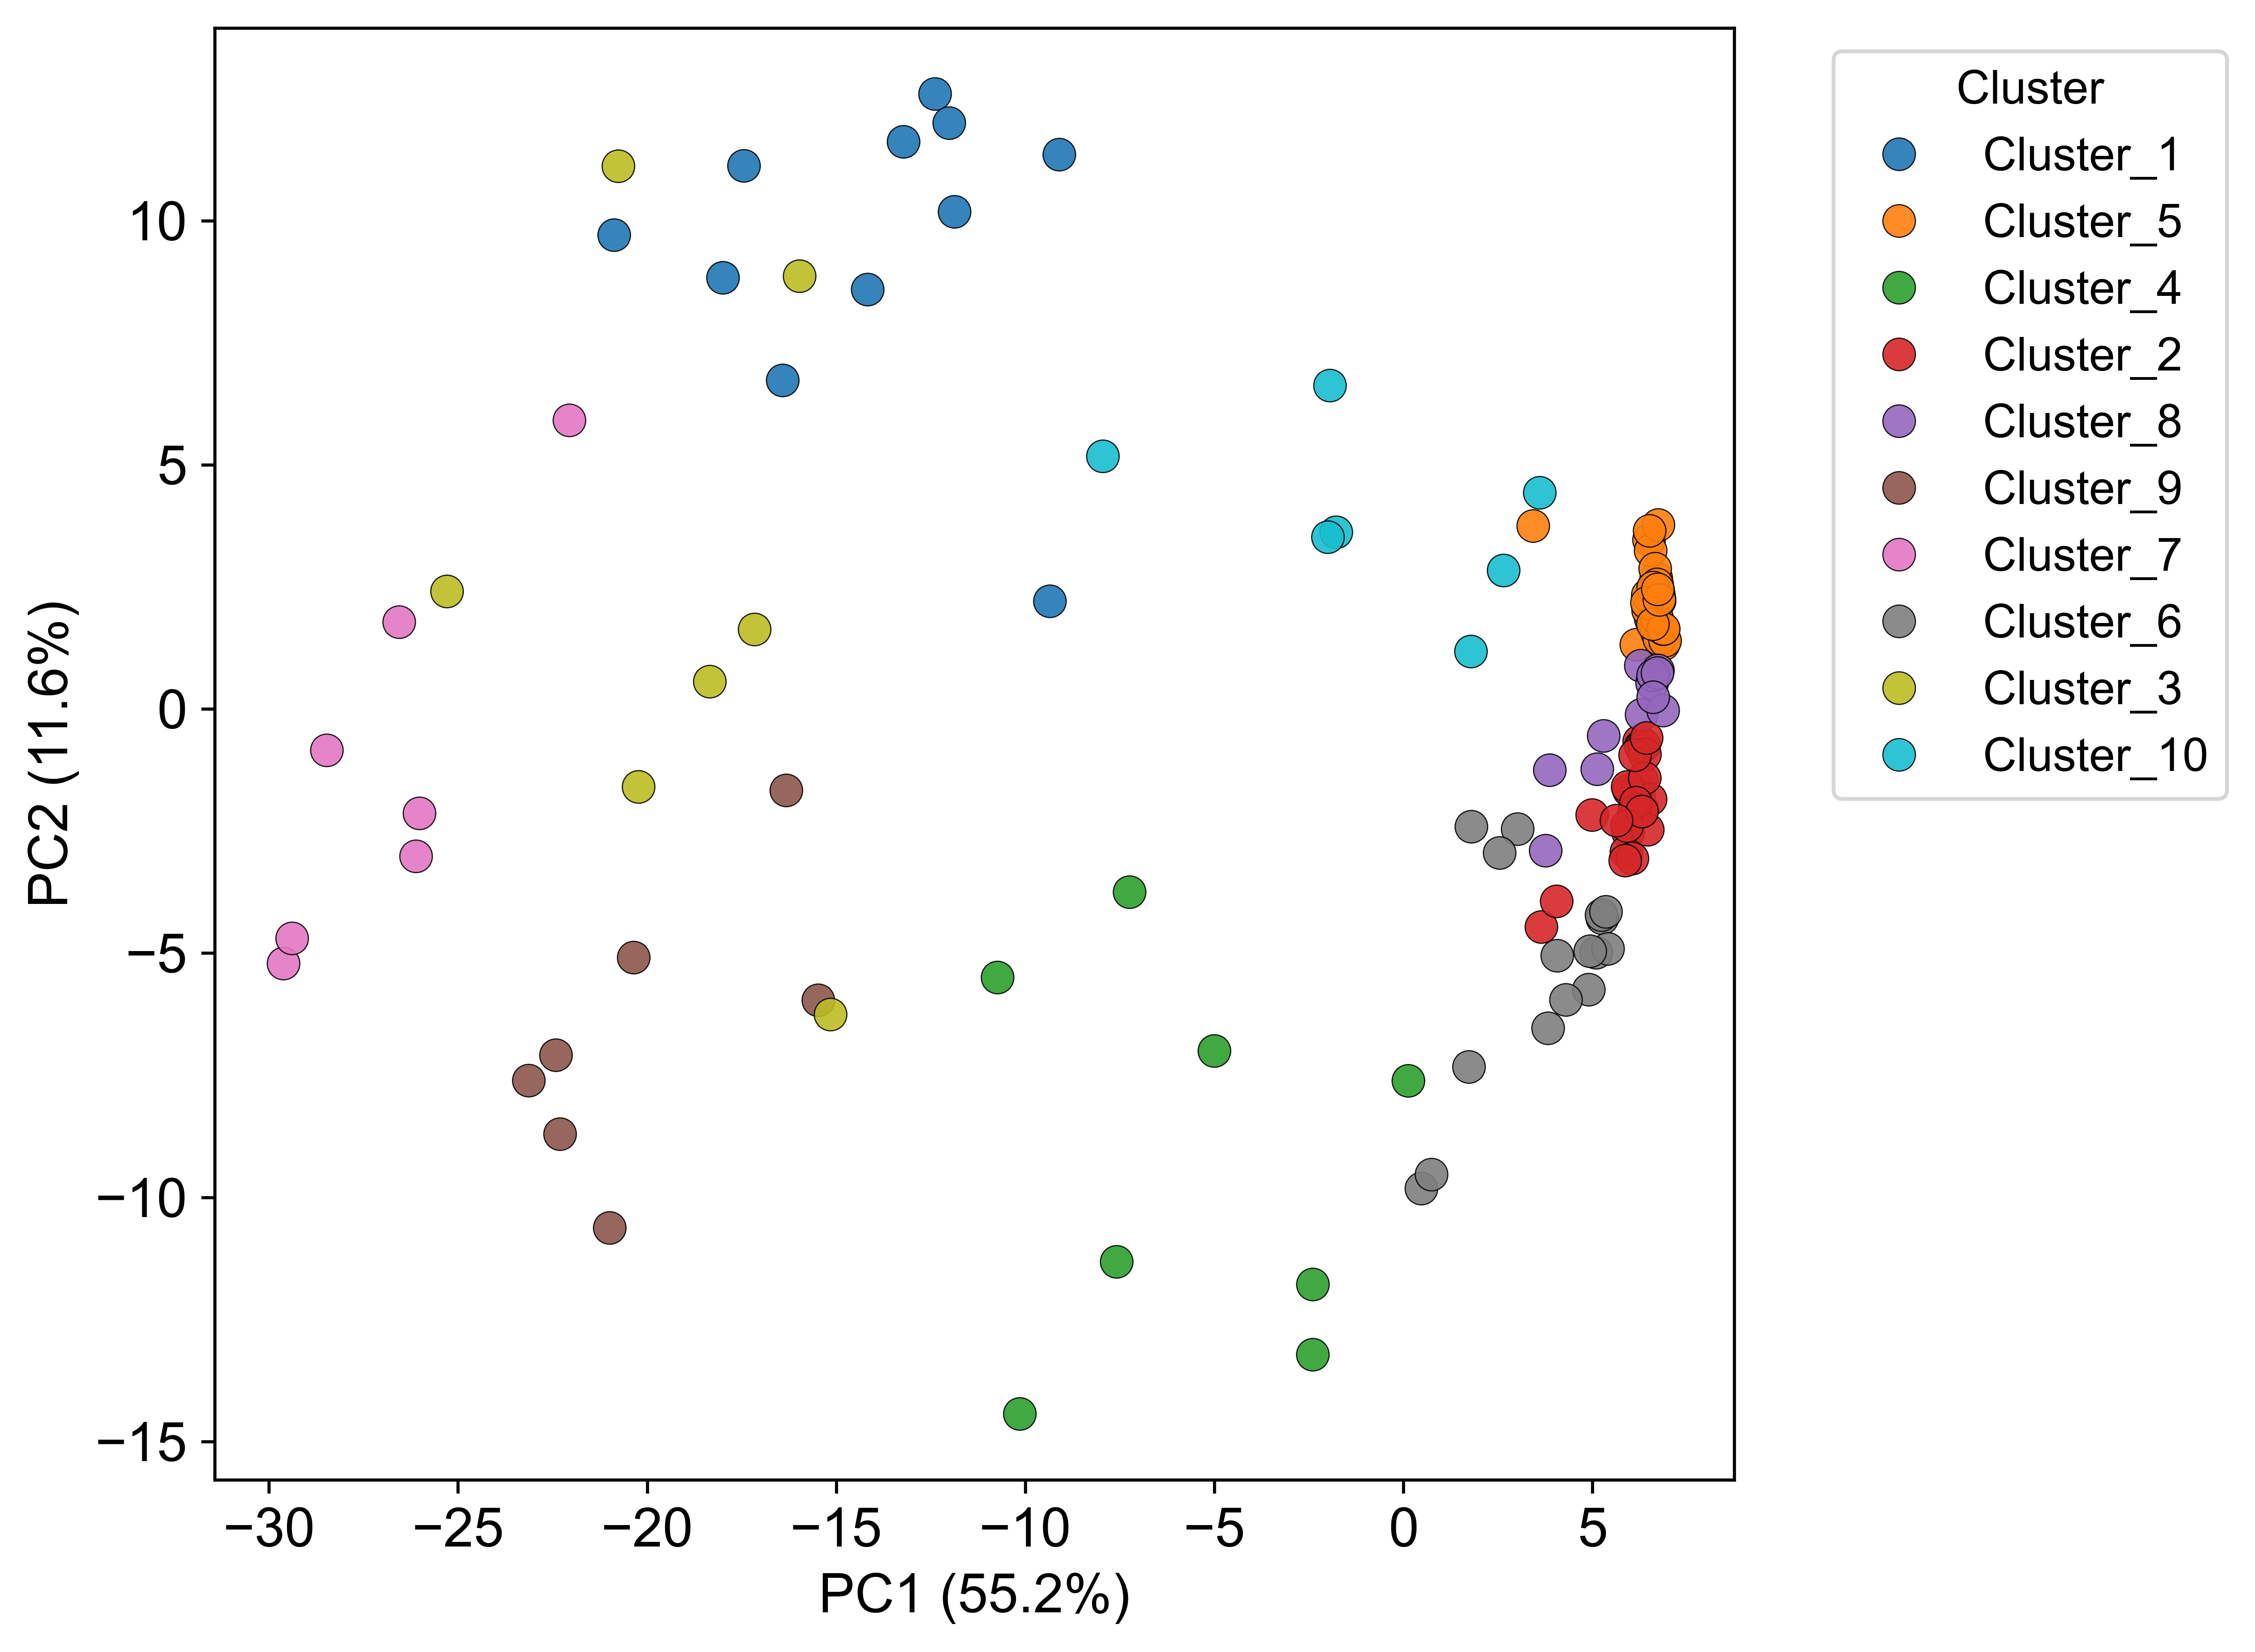

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8.2,6), dpi=600)

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=70,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.9
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontname="Arial",  fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontname="Arial",  fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(title="Cluster", bbox_to_anchor=(1.05,1), loc="upper left",   fontsize=12,  title_fontsize=12)
plt.tight_layout()

plt.savefig(f'{outdir3}/PCA_GO_clusters.svg',dpi=600, bbox_inches="tight")
plt.show()

C:\Users\jymbc\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


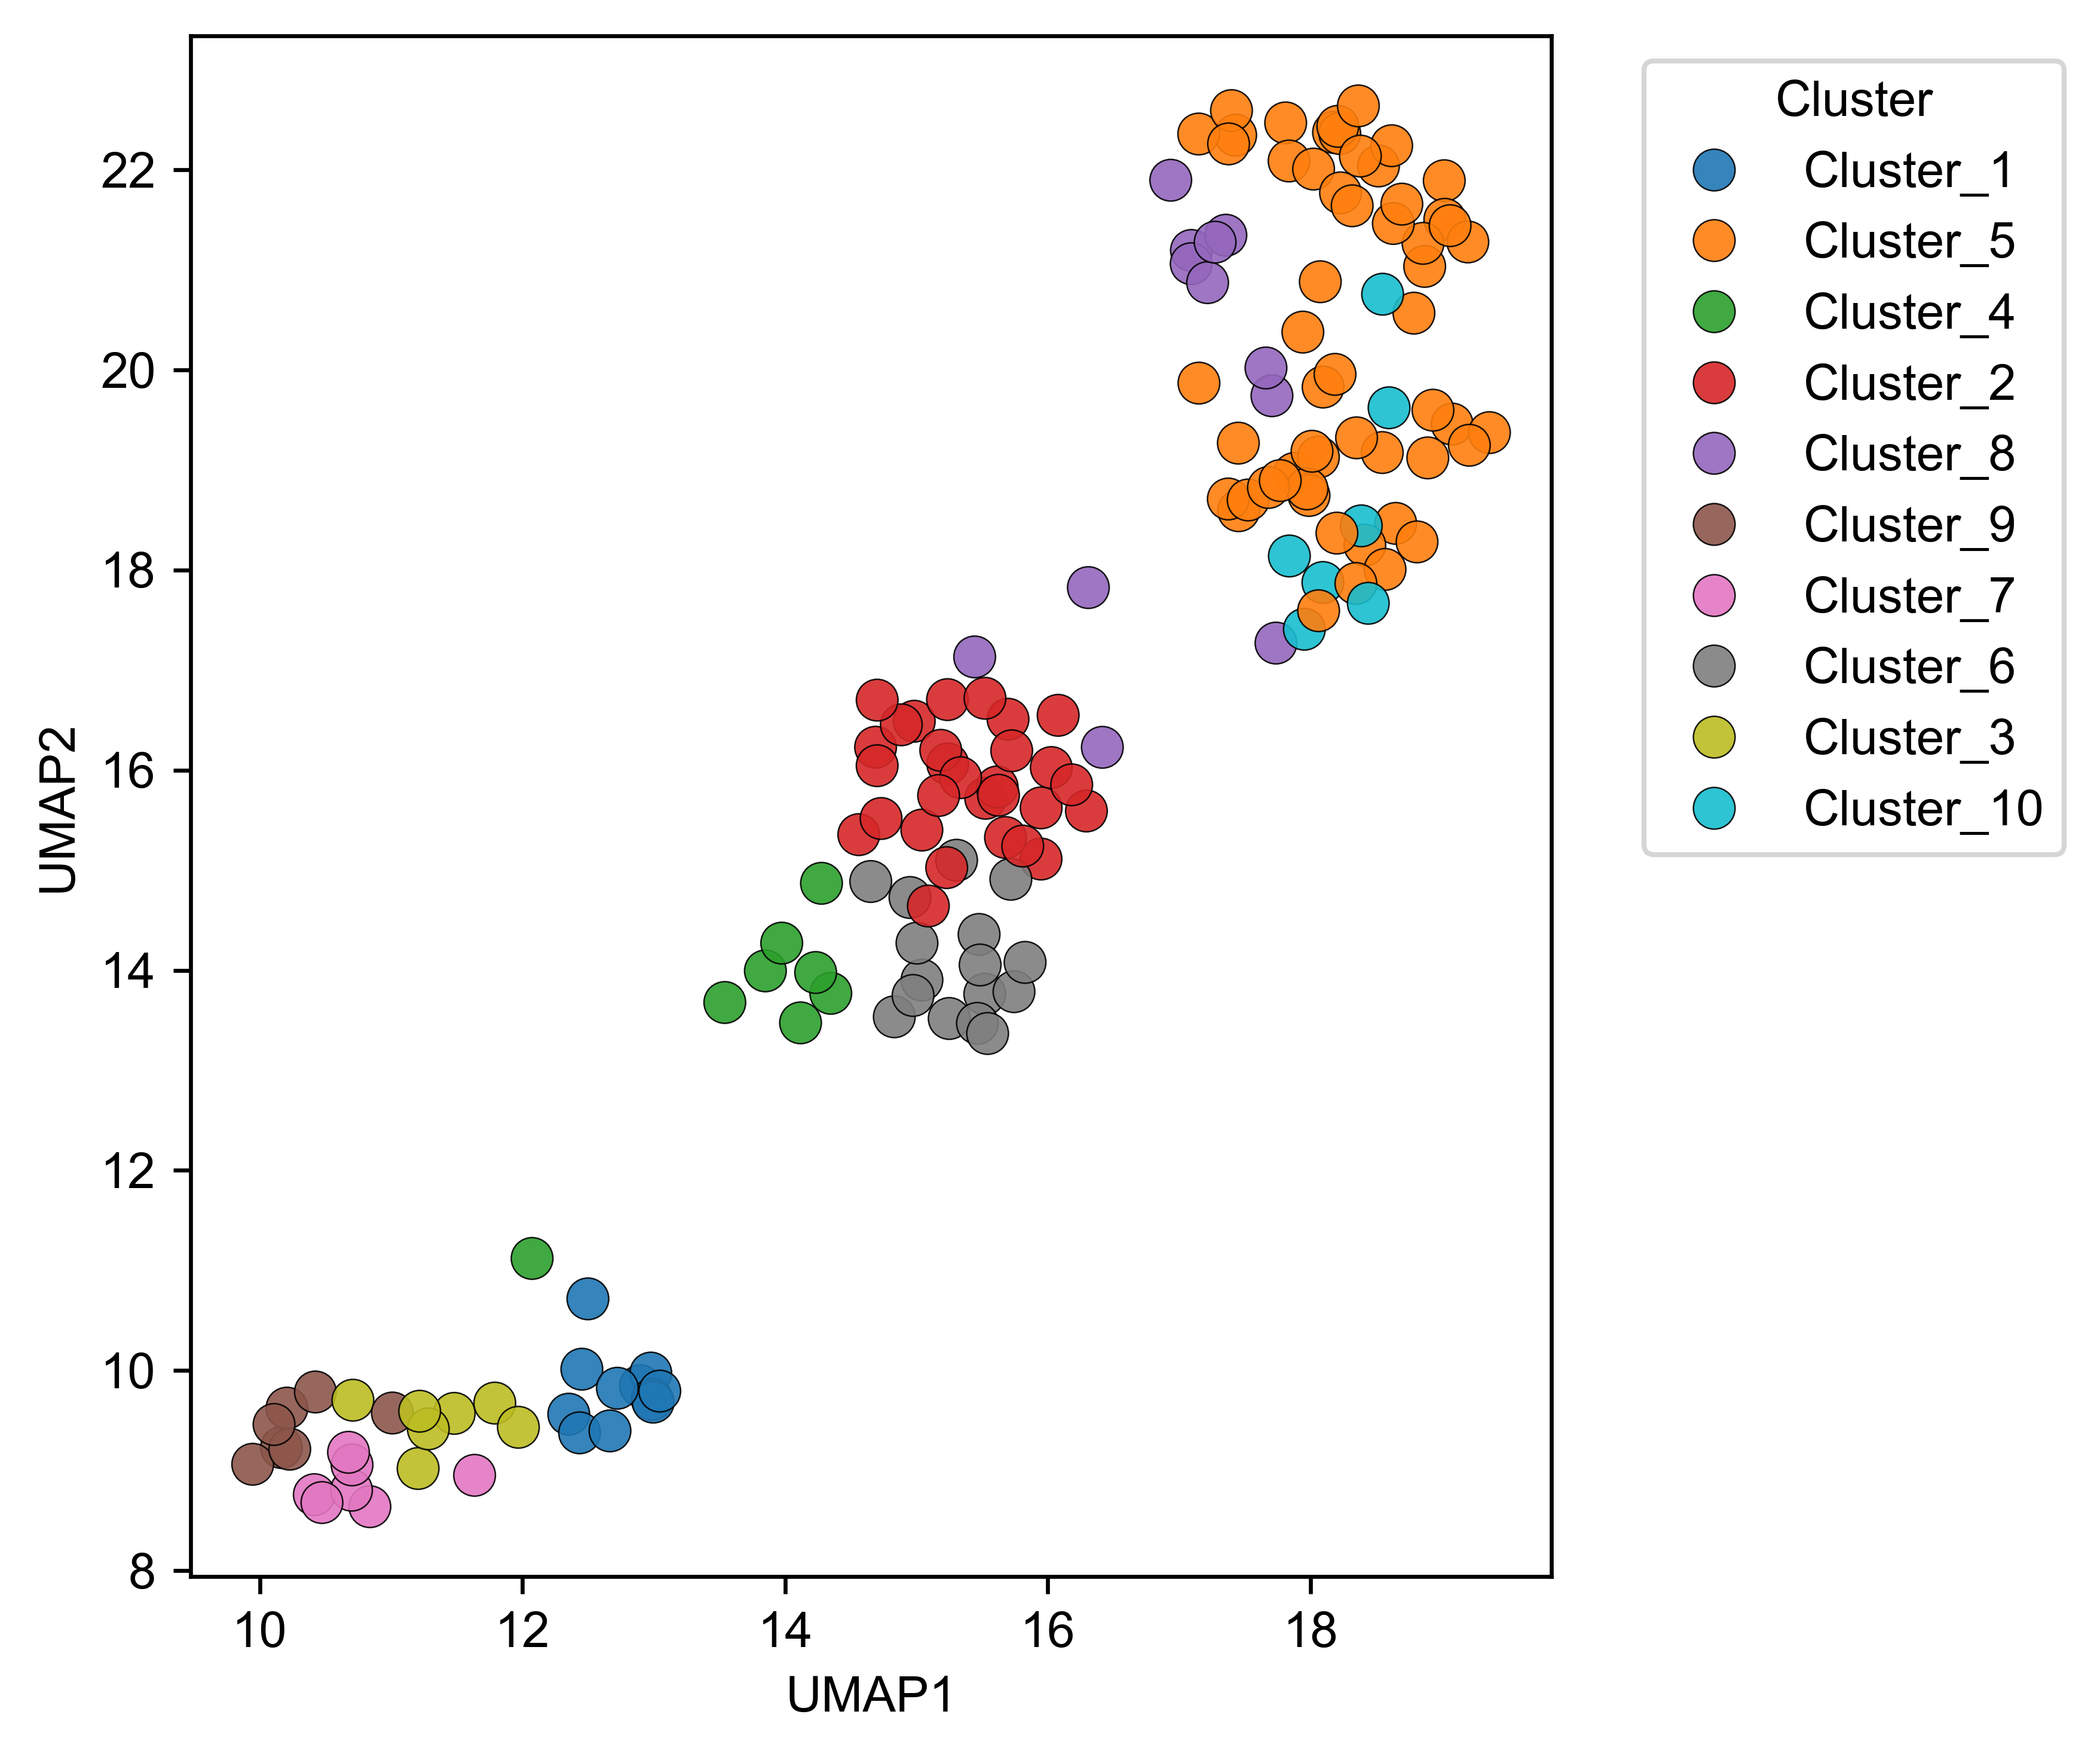

In [138]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.3,
    metric="euclidean",
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plot_df["UMAP1"] = X_umap[:, 0]
plot_df["UMAP2"] = X_umap[:, 1]


plt.figure(figsize=(6,5), dpi=600)

sns.scatterplot(
    data=plot_df,
    x="UMAP1",
    y="UMAP2",
    hue="cluster",
    palette="tab10",
    s=70,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.9
)

plt.xlabel("UMAP1", fontname="Arial")
plt.ylabel("UMAP2", fontname="Arial")

plt.legend(title="Cluster", bbox_to_anchor=(1.05,1), loc="upper left",fontsize = 12)
plt.tight_layout()

# plt.savefig("UMAP_GO_clusters.svg")
plt.show()

# check gene names in each GO term

In [248]:
gmt_file_go = r"E:\project8  Robotics and AI enable automation in modern proteomics\files\c5.go.bp.v2026.1.Hs.symbols.gmt" 

In [251]:
gmt_dict_go = {}

with open(gmt_file_go, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")
        gene_set_name = parts[0]
        description = parts[1]
        genes = parts[2:]
        gmt_dict_go[gene_set_name] = {
            "description": description,
            "genes": genes
        }

# 查看一个gene set
first_key = list(gmt_dict_go.keys())[0]
print(first_key)
print(gmt_dict_go[first_key]["description"])
print(gmt_dict_go[first_key]["genes"][:10])

GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS
https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS
['AASDHPPT', 'ALDH1L1', 'ALDH1L2', 'MTHFD1', 'MTHFD1L', 'MTHFD2L']


In [314]:
# keyword = "REGULATION_OF_NUCLEAR_DIVISION"
# keyword = "KERATINOCYTE_DIFFERENTIATION" 
keyword = "EPIDERMAL_CELL_DIFFERENTIATION"
matches = [k for k in gmt_dict_go.keys() if keyword.lower() in k.lower()]
print(matches)

['GOBP_EPIDERMAL_CELL_DIFFERENTIATION']


In [256]:


drug_matrix_fc = pd.read_csv(f'{file_path_manual}\drugs_log2FCvsDMSO.csv',index_col = 0 )

drug_matrix_fc

,6-Mercaptopurine,ATP (dimagnesium),Abemaciclib (methanesulfonate),Acetophenazine (dimaleate),Adiphenine (hydrochloride),Alcaftadine,Alizapride (hydrochloride),Almotriptan (malate),Ambroxol,Amcinonide,...,Umbralisib,Vadadustat,Vardenafil,Varenicline (Hydrochloride),Vasopressin,Vecuronium (bromide),Vemurafenib,Zanubrutinib,Î±-Lipoic Acid,Î³-Oryzanol
protein,,,,,,,,,,,,,,,,,,,,,
A0A096LP01,-0.213306,0.008645,-3.017222,-0.015191,0.114777,0.071537,0.331800,0.015241,0.390695,0.081722,...,0.216592,0.015072,0.150075,0.142743,0.004155,0.248929,0.000516,-0.002682,0.059616,0.164276
A0A1W2PQ72,0.115522,0.306942,-2.004011,-0.361997,-0.088654,0.049578,0.172095,0.176798,-0.150021,-0.301171,...,0.423664,0.244115,0.258773,0.085186,0.596208,0.016812,0.080860,-0.105197,0.477141,0.278834
A0A6Q8PH20,0.149915,0.122249,0.118387,-0.035126,0.030385,0.054527,-0.061516,-0.101658,-0.018070,0.072750,...,-0.160487,0.044659,-0.013053,-0.043081,-0.043805,-0.029516,0.217394,-0.129281,-0.097219,-0.013927
A0A804HLA8,-1.265195,-0.518644,2.148831,0.227840,-0.117882,0.123345,-0.149836,-0.573093,-0.090876,0.721948,...,0.176931,0.572170,-0.160314,-0.587093,-0.803674,0.265367,0.367898,-0.168647,-0.513196,-0.745572
A0AAG2UWQ9,-0.040252,-0.158627,0.303620,-0.065158,-0.115779,-0.137628,-0.016961,-0.100565,-0.070702,-0.087683,...,-0.169570,-0.208312,-0.112688,-0.128213,-0.132926,-0.074991,0.053352,-0.095988,-0.047703,-0.063660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cRAP-O77727,0.001737,0.064509,0.836704,-0.244200,-0.251757,-0.265507,-0.030898,0.167916,0.406341,-0.153279,...,0.253493,-0.094773,-0.603133,-0.058427,0.018114,-0.289101,0.337533,0.112992,-0.506536,-0.545358
cRAP-P00761,-0.019955,-0.297194,1.437949,-0.304266,-0.402693,-0.497262,-0.542009,-0.354430,-0.349656,-0.277576,...,-0.341432,-0.367448,-0.392691,-0.351410,-0.502804,-0.259420,-0.233930,-0.333884,-0.329545,-0.418121
cRAP-P02769,0.297146,-0.124069,0.276433,-0.516238,0.048361,-0.494179,-0.734212,-0.729552,-0.063911,-0.788489,...,-0.600713,-0.698639,0.094183,-0.592443,-0.672193,-0.441189,0.168048,-1.058147,-0.368480,0.053454


In [4]:
df_raw = pd.read_csv(f'{file_path_manual}\imputed_normalized_BatchCorrected_drugnames_log2.csv', index_col = 0)
df_raw

,Blue1_QC10,Blue1_QC11,Blue1_QC12,Blue1_QC1,Blue1_QC2,Blue1_QC3,Blue1_QC4,Blue1_QC5,Blue1_QC6,Blue1_QC7,...,Ambroxol_6,Pergolide (mesylate)_6,Liranaftate_6,Efavirenz_6,Saquinavir (mesylate)_6,Remdesivir_6,Azelastine (hydrochloride)_6,Cobicistat_6,Oteseconazole_6,Paritaprevir_6
A0A096LP01,18.620326,18.776928,18.607869,18.221064,17.967479,18.212336,18.216982,18.406277,17.913023,18.449606,...,19.278568,20.342160,20.393694,19.706414,19.659407,18.640554,18.610459,19.149750,19.099014,20.285495
A0A1W2PQ72,14.349181,13.921408,13.380003,14.368877,11.937484,11.937484,14.382759,13.759432,14.371761,14.050381,...,11.705238,14.344348,13.700979,14.130194,13.314018,15.059541,11.705238,14.259131,14.294827,13.502522
A0A6Q8PH20,23.991142,24.035089,24.074514,24.143384,24.174264,24.037204,24.143907,24.008855,24.081099,24.104229,...,24.190344,24.174656,24.351901,24.146769,24.146687,23.978751,24.373564,24.227401,24.332700,24.227509
A0A804HLA8,13.265411,15.508955,15.741729,18.148712,17.158548,16.500722,16.738076,15.545974,15.565808,13.265411,...,17.210423,16.486332,16.650104,15.332938,17.439829,17.363834,17.133226,16.771307,16.640912,17.017297
A0AAG2UWQ9,21.827296,21.851849,21.749314,21.732760,21.888522,21.672432,21.832786,21.608737,21.859803,21.942685,...,22.088201,22.068704,22.097893,21.941897,22.189372,22.372878,22.161468,22.016759,21.969496,22.028456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cRAP-O77727,23.895848,24.618162,25.241632,24.858435,24.709403,24.101740,24.313215,23.971408,23.731551,23.842479,...,23.945499,23.739814,24.729896,23.742509,23.719181,24.487192,23.599526,24.193465,23.334149,24.852104
cRAP-P00761,31.213427,31.299163,31.256789,32.015663,31.679816,31.193790,31.298763,31.050816,31.214082,31.247418,...,31.934207,31.066981,31.132397,31.204219,31.502320,32.057307,31.555712,31.542725,31.635988,31.243903
cRAP-P02769,28.087314,28.167868,28.181955,27.897735,28.005322,28.042421,28.052371,28.104011,28.126789,28.184589,...,27.456403,27.823305,27.884724,27.977558,27.864848,28.361139,27.558812,27.511994,27.242526,27.296984
cRAP-P12763,29.023275,29.045106,29.080343,28.847221,29.054662,29.087015,29.056471,28.990219,29.038474,29.078065,...,29.334758,29.990635,30.173989,30.011180,29.962632,30.762845,29.378032,29.210442,28.843467,28.917130


In [5]:
import pandas as pd

# 找 DMSO 列
dmso_cols = [c for c in df_raw.columns if "DMSO" in c]

# 计算 DMSO mean（每个 protein 一行）
dmso_mean = df_raw[dmso_cols].mean(axis=1)

# 找所有 drug replicate 列（排除 DMSO）
drug_cols = [c for c in df_raw.columns if "DMSO" not in c]

# 逐列减去 DMSO mean
df_fc = df_raw.copy()

for col in drug_cols:
    df_fc[col] = df_raw[col] - dmso_mean
df_fc

,Blue1_QC10,Blue1_QC11,Blue1_QC12,Blue1_QC1,Blue1_QC2,Blue1_QC3,Blue1_QC4,Blue1_QC5,Blue1_QC6,Blue1_QC7,...,Ambroxol_6,Pergolide (mesylate)_6,Liranaftate_6,Efavirenz_6,Saquinavir (mesylate)_6,Remdesivir_6,Azelastine (hydrochloride)_6,Cobicistat_6,Oteseconazole_6,Paritaprevir_6
A0A096LP01,-1.035622,-0.879020,-1.048080,-1.434885,-1.688470,-1.443612,-1.438967,-1.249672,-1.742925,-1.206343,...,-0.377380,0.686211,0.737745,0.050465,0.003458,-1.015395,-1.045490,-0.506198,-0.556935,0.629546
A0A1W2PQ72,0.508400,0.080627,-0.460779,0.528096,-1.903297,-1.903297,0.541978,-0.081350,0.530980,0.209599,...,-2.135543,0.503567,-0.139803,0.289412,-0.526763,1.218760,-2.135543,0.418350,0.454046,-0.338260
A0A6Q8PH20,-0.188097,-0.144150,-0.104725,-0.035855,-0.004975,-0.142035,-0.035332,-0.170384,-0.098140,-0.075009,...,0.011105,-0.004583,0.172662,-0.032470,-0.032552,-0.200488,0.194326,0.048162,0.153462,0.048270
A0A804HLA8,-3.289623,-1.046078,-0.813305,1.593678,0.603514,-0.054312,0.183042,-1.009060,-0.989226,-3.289623,...,0.655389,-0.068701,0.095070,-1.222096,0.884795,0.808800,0.578192,0.216273,0.085878,0.462263
A0AAG2UWQ9,-0.340613,-0.316060,-0.418595,-0.435149,-0.279388,-0.495477,-0.335124,-0.559173,-0.308107,-0.225224,...,-0.079708,-0.099205,-0.070017,-0.226013,0.021462,0.204968,-0.006442,-0.151151,-0.198413,-0.139454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cRAP-O77727,-0.244554,0.477760,1.101230,0.718032,0.569001,-0.038662,0.172812,-0.168994,-0.408851,-0.297923,...,-0.194903,-0.400588,0.589494,-0.397894,-0.421221,0.346790,-0.540876,0.053063,-0.806253,0.711702
cRAP-P00761,-0.395055,-0.309319,-0.351693,0.407182,0.071334,-0.414692,-0.309719,-0.557666,-0.394399,-0.361064,...,0.325726,-0.541501,-0.476085,-0.404262,-0.106162,0.448825,-0.052770,-0.065757,0.027506,-0.364579
cRAP-P02769,0.098954,0.179508,0.193595,-0.090625,0.016962,0.054061,0.064011,0.115651,0.138429,0.196229,...,-0.531957,-0.165055,-0.103637,-0.010802,-0.123513,0.372779,-0.429548,-0.476366,-0.745834,-0.691376
cRAP-P12763,-1.016584,-0.994753,-0.959517,-1.192638,-0.985197,-0.952845,-0.983388,-1.049641,-1.001385,-0.961794,...,-0.705101,-0.049224,0.134130,-0.028679,-0.077227,0.722985,-0.661827,-0.829417,-1.196392,-1.122729


In [6]:
map_df = pd.read_csv(f'{file_path_manual}/uniprot_to_gene.csv', index_col = 0)  # uniprot_to_gene map

In [7]:
map_sub = map_df[["query", "symbol"]].copy()

map_sub["query"] = map_sub["query"].astype(str).str.strip()
map_sub["symbol"] = map_sub["symbol"].astype(str).str.strip()

# 把无效标记统一成缺失值
map_sub["symbol"] = map_sub["symbol"].replace({
    "": np.nan,
    "nan": np.nan,
    "None": np.nan,
    "NO": np.nan,
    "No": np.nan,
    "no": np.nan
})

print(map_sub.shape)
display(map_sub.head())

(8146, 2)


,query,symbol
0,A0A096LP01,SMIM26
1,A0A1W2PQ72,MSANTD7
2,A0A6Q8PH20,CAST
3,A0A804HLA8,GNG5B
4,A0AAG2UWQ9,NKRF


In [8]:
df_mapped = df_fc.copy()

df_mapped["protein"] = df_mapped.index

df_mapped["protein"] = df_mapped["protein"].astype(str).str.strip()

df_mapped = df_mapped.merge(
    map_sub,
    how="left",
    left_on="protein",
    right_on="query"
)

df_mapped = df_mapped.rename(columns={"symbol": "gene_symbol"})

print(df_mapped.shape)
display(df_mapped.head())

(8146, 1213)


,Blue1_QC10,Blue1_QC11,Blue1_QC12,Blue1_QC1,Blue1_QC2,Blue1_QC3,Blue1_QC4,Blue1_QC5,Blue1_QC6,Blue1_QC7,...,Efavirenz_6,Saquinavir (mesylate)_6,Remdesivir_6,Azelastine (hydrochloride)_6,Cobicistat_6,Oteseconazole_6,Paritaprevir_6,protein,query,gene_symbol
0,-1.035622,-0.879020,-1.048080,-1.434885,-1.688470,-1.443612,-1.438967,-1.249672,-1.742925,-1.206343,...,0.050465,0.003458,-1.015395,-1.045490,-0.506198,-0.556935,0.629546,A0A096LP01,A0A096LP01,SMIM26
1,0.508400,0.080627,-0.460779,0.528096,-1.903297,-1.903297,0.541978,-0.081350,0.530980,0.209599,...,0.289412,-0.526763,1.218760,-2.135543,0.418350,0.454046,-0.338260,A0A1W2PQ72,A0A1W2PQ72,MSANTD7
2,-0.188097,-0.144150,-0.104725,-0.035855,-0.004975,-0.142035,-0.035332,-0.170384,-0.098140,-0.075009,...,-0.032470,-0.032552,-0.200488,0.194326,0.048162,0.153462,0.048270,A0A6Q8PH20,A0A6Q8PH20,CAST
3,-3.289623,-1.046078,-0.813305,1.593678,0.603514,-0.054312,0.183042,-1.009060,-0.989226,-3.289623,...,-1.222096,0.884795,0.808800,0.578192,0.216273,0.085878,0.462263,A0A804HLA8,A0A804HLA8,GNG5B
4,-0.340613,-0.316060,-0.418595,-0.435149,-0.279388,-0.495477,-0.335124,-0.559173,-0.308107,-0.225224,...,-0.226013,0.021462,0.204968,-0.006442,-0.151151,-0.198413,-0.139454,A0AAG2UWQ9,A0AAG2UWQ9,NKRF


### locate columns and rows by gene and drug name

In [355]:
import pandas as pd

gene = ["PLK1", "BIRC5", "CDC20", "CCNB1","NUF2","BUB1","AURKA"]
drugs = ["Abemaciclib", "Binimetinib", "Erlotinib", "Neratinib", "Olmutinib", "Mobocertinib", "Lonafarnib"]

# 匹配药物列（支持 replicate）
drug_cols = [c for c in df_mapped.columns if any(c.startswith(drug) for drug in drugs)]

# 提取目标基因和药物
sub_df1 = df_mapped.loc[df_mapped["gene_symbol"].isin(gene), ["gene_symbol"] + drug_cols].copy()

# 按指定基因顺序排序
sub_df1["gene_symbol"] = pd.Categorical(sub_df["gene_symbol"], categories=gene, ordered=True)
sub_df1 = sub_df1.sort_values("gene_symbol")

sub_df1




,gene_symbol,Neratinib_1,Lonafarnib_1,Abemaciclib (methanesulfonate)_1,Olmutinib_1,Neratinib_2,Lonafarnib_2,Abemaciclib (methanesulfonate)_2,Olmutinib_2,Neratinib_3,...,Binimetinib_3,Erlotinib (Hydrochloride)_4,Mobocertinib (succinate)_4,Binimetinib_4,Erlotinib (Hydrochloride)_5,Mobocertinib (succinate)_5,Binimetinib_5,Erlotinib (Hydrochloride)_6,Mobocertinib (succinate)_6,Binimetinib_6
256,PLK1,-0.820446,-0.963912,-1.901909,-1.003717,-0.710432,-0.834576,-2.006507,-0.871268,-0.730197,...,-1.301326,-1.215041,-1.620935,-1.332784,-0.990313,-0.897691,-1.092655,-1.044845,-1.747645,-1.053591
340,BIRC5,-1.004092,-1.479586,-4.240182,-1.975222,-1.752863,-1.422398,-1.490677,-1.944455,-1.054441,...,-0.836082,-3.194962,-5.380792,-0.673722,-1.844515,-4.266001,-1.154687,-2.132549,-2.132549,-2.132549
450,CDC20,-0.896229,-1.011577,-3.266230,-1.709275,-1.249844,-1.446240,-2.535853,-1.693885,-0.968343,...,-1.613624,-1.567040,-3.543211,-1.104980,-1.419921,-1.185526,-1.732429,-1.369600,-3.479341,-1.037504
1412,CCNB1,-0.983991,-1.079839,-1.096794,-0.820366,-0.979958,-0.806010,-0.942368,-0.780050,-0.685428,...,-1.051596,-1.133620,-1.966393,-1.292669,-1.261541,-1.364090,-1.326123,-0.977299,-1.720682,-1.095304
2353,NUF2,-1.107008,-1.963626,-1.498840,-1.421634,-1.106537,-1.783704,-1.630572,-1.248842,-0.960720,...,-1.574765,-1.441317,-1.627278,-1.657563,-1.623299,-1.146811,-1.667226,-1.489630,-2.220449,-1.443388
2983,BUB1,-0.834606,-1.282426,-2.513718,-1.612735,-0.768157,-1.154646,-2.280034,-1.763058,-0.597075,...,-1.846734,-1.124335,-1.892097,-1.651203,-1.477491,-1.455237,-1.767196,-1.244907,-1.429964,-1.643772
6405,AURKA,-0.772407,-1.019822,-1.259306,-0.860502,-0.965694,-0.924203,-1.446398,-1.116347,-0.829227,...,-0.449371,-1.276674,-0.908321,-0.901630,-1.167509,-0.959367,-0.639614,-1.062949,-0.923539,-0.634446


In [360]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gene_log2fc_pooled(
    sub_df,
    gene_set,
    gene_col="gene_symbol",
    figsize=(6, 4),
    tick_fontsize = 12,
    color_name = "#3CADE0",
    save_path=None
):
    # 只保留目标基因
    plot_df = sub_df.loc[sub_df[gene_col].isin(gene_set)].copy()

    # 保证基因顺序
    plot_df[gene_col] = pd.Categorical(plot_df[gene_col], categories=gene_set, ordered=True)
    plot_df = plot_df.sort_values(gene_col)
    plot_df[gene_col] = plot_df[gene_col].cat.remove_unused_categories()

    # 除 gene_symbol 外，其余都看作药物列
    value_cols = [c for c in plot_df.columns if c != gene_col]

    # 宽表转长表
    long_df = plot_df.melt(
        id_vars=gene_col,
        value_vars=value_cols,
        var_name="drug_rep",
        value_name="log2FC"
    ).dropna()

    # 作图
    sns.set(style="white", font_scale=1.1)
    fig, ax = plt.subplots(figsize=figsize)

    # boxplot
    sns.boxplot(
        data=long_df,
        x=gene_col,
        y="log2FC",
        color="white",
        width=0.5,
        showfliers=False,
        linewidth=2,
        ax=ax
    )

    # scatter / strip
    sns.stripplot(
        data=long_df,
        x=gene_col,
        y="log2FC",
        color= color_name,
        size=7,
        alpha=0.9,
        jitter=0.22,
        edgecolor="gray",
        linewidth=0.5,
        ax=ax
    )

    # y=0 参考线
    ax.axhline(0, color="gray", linestyle="--", linewidth=2)

    ax.set_xlabel("")
    ax.set_ylabel(r"Log$_2$(FC) versus DMSO",fontsize = tick_fontsize)
    ax.tick_params(axis="x", rotation=0, labelsize=tick_fontsize)
    ax.tick_params(axis="y", labelsize=tick_fontsize)

    sns.despine(ax=ax)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    return fig, ax, long_df

C:\Users\jymbc\AppData\Local\Temp\ipykernel_57500\2641329134.py:50: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


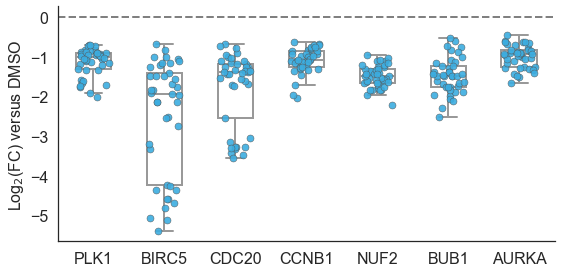

In [375]:
figure_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\figures"

fig, ax, long_df = plot_gene_log2fc_pooled(
    sub_df=sub_df1,
    gene_set=gene,
    gene_col="gene_symbol",
    figsize=(8, 4),
    tick_fontsize = 16,
    color_name = "#3CADE0",
    save_path=f'{figure_path}/GO_gene_jitter_plot_cluster1.svg'
)

In [377]:
gene2 =[
    "HMGCR",
    "SQLE",
    "LDLR",
    "FDFT1",
    "DHCR24",
    "SCARB1",
    "ABCA1",
    "SREBF2"
]

drugs = [
    "Amiodarone",
    "Amodiaquine",
    "Haloperidol",
    "Lapatinib",
    "Oteseconazole",
    "Saquinavir",
    "Desloratadine",
    "Benztropine"]

# 匹配药物列（支持 replicate）
drug_cols = [c for c in df_mapped.columns if any(c.startswith(drug) for drug in drugs)]

# 提取目标基因和药物
sub_df2 = df_mapped.loc[df_mapped["gene_symbol"].isin(gene2), ["gene_symbol"] + drug_cols].copy()

# 按指定基因顺序排序
sub_df2["gene_symbol"] = pd.Categorical(sub_df2["gene_symbol"], categories=gene2, ordered=True)
sub_df2 = sub_df2.sort_values("gene_symbol")

sub_df2

,gene_symbol,Haloperidol_1,Haloperidol_2,Haloperidol_3,Haloperidol_4,Haloperidol_5,Haloperidol_6,Benztropine (mesylate)_1,Amiodarone (hydrochloride)_1,Amodiaquine (dihydrochloride)_1,...,Saquinavir (mesylate)_2,Oteseconazole_2,Saquinavir (mesylate)_3,Oteseconazole_3,Saquinavir (mesylate)_4,Oteseconazole_4,Saquinavir (mesylate)_5,Oteseconazole_5,Saquinavir (mesylate)_6,Oteseconazole_6
1080,HMGCR,1.642161,1.457022,1.308631,1.287792,1.438059,1.298185,0.408471,1.480028,0.845645,...,0.327260,0.782228,0.590271,0.833212,0.133577,0.876182,0.063999,0.583109,0.206440,0.654614
3266,SQLE,1.610597,1.538761,1.468359,1.522190,1.499178,1.513235,1.052523,1.272126,0.950921,...,0.306016,0.630592,0.482157,0.741905,0.233442,0.646088,0.249370,0.673857,0.319425,0.617027
1039,LDLR,1.322098,1.291363,1.282823,1.270107,1.277374,1.380908,1.403675,1.710532,1.770497,...,0.305824,0.428149,0.984164,1.111314,0.347349,0.567629,0.297507,0.664785,0.622077,0.642965
1954,FDFT1,1.545071,1.470069,1.444360,1.522419,1.556731,1.589418,1.437147,1.348022,0.995176,...,0.232363,0.200177,0.588233,0.677415,0.273997,0.463497,0.267981,0.390885,0.416403,0.459931
3423,DHCR24,0.603229,0.481453,0.519719,0.654475,0.555065,0.662548,0.344364,0.297251,0.461953,...,0.121892,0.197873,0.136422,0.224312,-0.001160,0.182655,0.002587,0.150830,0.025609,0.181329
5202,SCARB1,0.702074,0.583224,0.546129,0.671373,0.497662,0.519410,0.388299,0.556464,0.470884,...,0.055869,0.052928,0.289440,0.262020,0.034560,0.099362,0.121744,0.134905,0.242687,0.120086
913,ABCA1,0.382257,0.152256,0.332603,0.298215,0.144840,0.240416,0.371464,0.592105,0.551110,...,0.502703,0.143796,0.579570,0.335500,0.452969,0.277285,0.231047,0.218607,0.347260,0.323448
2971,SREBF2,0.658780,0.309369,0.437176,0.422087,0.561618,0.615156,0.540222,0.721601,0.792516,...,-0.074985,0.398594,0.642071,0.829115,-0.141105,0.752311,-0.297106,0.950233,-0.064771,0.481379


C:\Users\jymbc\AppData\Local\Temp\ipykernel_57500\2641329134.py:50: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


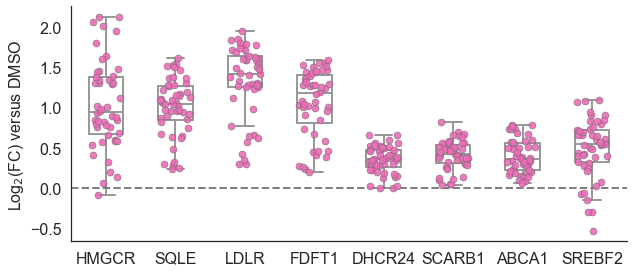

In [378]:
figure_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\figures"

fig, ax, long_df = plot_gene_log2fc_pooled(
    sub_df=sub_df2,
    gene_set=gene2,
    gene_col="gene_symbol",
    figsize=(9, 4),
    tick_fontsize = 16,
    color_name = "#EB6CB6",
    save_path=f'{figure_path}/GO_gene_jitter_plot_cluster7.svg'
)

In [9]:
df_mapped

,Blue1_QC10,Blue1_QC11,Blue1_QC12,Blue1_QC1,Blue1_QC2,Blue1_QC3,Blue1_QC4,Blue1_QC5,Blue1_QC6,Blue1_QC7,...,Efavirenz_6,Saquinavir (mesylate)_6,Remdesivir_6,Azelastine (hydrochloride)_6,Cobicistat_6,Oteseconazole_6,Paritaprevir_6,protein,query,gene_symbol
0,-1.035622,-0.879020,-1.048080,-1.434885,-1.688470,-1.443612,-1.438967,-1.249672,-1.742925,-1.206343,...,0.050465,0.003458,-1.015395,-1.045490,-0.506198,-0.556935,0.629546,A0A096LP01,A0A096LP01,SMIM26
1,0.508400,0.080627,-0.460779,0.528096,-1.903297,-1.903297,0.541978,-0.081350,0.530980,0.209599,...,0.289412,-0.526763,1.218760,-2.135543,0.418350,0.454046,-0.338260,A0A1W2PQ72,A0A1W2PQ72,MSANTD7
2,-0.188097,-0.144150,-0.104725,-0.035855,-0.004975,-0.142035,-0.035332,-0.170384,-0.098140,-0.075009,...,-0.032470,-0.032552,-0.200488,0.194326,0.048162,0.153462,0.048270,A0A6Q8PH20,A0A6Q8PH20,CAST
3,-3.289623,-1.046078,-0.813305,1.593678,0.603514,-0.054312,0.183042,-1.009060,-0.989226,-3.289623,...,-1.222096,0.884795,0.808800,0.578192,0.216273,0.085878,0.462263,A0A804HLA8,A0A804HLA8,GNG5B
4,-0.340613,-0.316060,-0.418595,-0.435149,-0.279388,-0.495477,-0.335124,-0.559173,-0.308107,-0.225224,...,-0.226013,0.021462,0.204968,-0.006442,-0.151151,-0.198413,-0.139454,A0AAG2UWQ9,A0AAG2UWQ9,NKRF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8141,-0.244554,0.477760,1.101230,0.718032,0.569001,-0.038662,0.172812,-0.168994,-0.408851,-0.297923,...,-0.397894,-0.421221,0.346790,-0.540876,0.053063,-0.806253,0.711702,cRAP-O77727,NaN,NaN
8142,-0.395055,-0.309319,-0.351693,0.407182,0.071334,-0.414692,-0.309719,-0.557666,-0.394399,-0.361064,...,-0.404262,-0.106162,0.448825,-0.052770,-0.065757,0.027506,-0.364579,cRAP-P00761,NaN,NaN
8143,0.098954,0.179508,0.193595,-0.090625,0.016962,0.054061,0.064011,0.115651,0.138429,0.196229,...,-0.010802,-0.123513,0.372779,-0.429548,-0.476366,-0.745834,-0.691376,cRAP-P02769,NaN,NaN
8144,-1.016584,-0.994753,-0.959517,-1.192638,-0.985197,-0.952845,-0.983388,-1.049641,-1.001385,-0.961794,...,-0.028679,-0.077227,0.722985,-0.661827,-0.829417,-1.196392,-1.122729,cRAP-P12763,NaN,NaN


# plot select gene of drug versus DMSO 

In [14]:
df_raw["gene"] = df_mapped.gene_symbol.tolist()
df_raw

,Blue1_QC10,Blue1_QC11,Blue1_QC12,Blue1_QC1,Blue1_QC2,Blue1_QC3,Blue1_QC4,Blue1_QC5,Blue1_QC6,Blue1_QC7,...,Pergolide (mesylate)_6,Liranaftate_6,Efavirenz_6,Saquinavir (mesylate)_6,Remdesivir_6,Azelastine (hydrochloride)_6,Cobicistat_6,Oteseconazole_6,Paritaprevir_6,gene
A0A096LP01,18.620326,18.776928,18.607869,18.221064,17.967479,18.212336,18.216982,18.406277,17.913023,18.449606,...,20.342160,20.393694,19.706414,19.659407,18.640554,18.610459,19.149750,19.099014,20.285495,SMIM26
A0A1W2PQ72,14.349181,13.921408,13.380003,14.368877,11.937484,11.937484,14.382759,13.759432,14.371761,14.050381,...,14.344348,13.700979,14.130194,13.314018,15.059541,11.705238,14.259131,14.294827,13.502522,MSANTD7
A0A6Q8PH20,23.991142,24.035089,24.074514,24.143384,24.174264,24.037204,24.143907,24.008855,24.081099,24.104229,...,24.174656,24.351901,24.146769,24.146687,23.978751,24.373564,24.227401,24.332700,24.227509,CAST
A0A804HLA8,13.265411,15.508955,15.741729,18.148712,17.158548,16.500722,16.738076,15.545974,15.565808,13.265411,...,16.486332,16.650104,15.332938,17.439829,17.363834,17.133226,16.771307,16.640912,17.017297,GNG5B
A0AAG2UWQ9,21.827296,21.851849,21.749314,21.732760,21.888522,21.672432,21.832786,21.608737,21.859803,21.942685,...,22.068704,22.097893,21.941897,22.189372,22.372878,22.161468,22.016759,21.969496,22.028456,NKRF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cRAP-O77727,23.895848,24.618162,25.241632,24.858435,24.709403,24.101740,24.313215,23.971408,23.731551,23.842479,...,23.739814,24.729896,23.742509,23.719181,24.487192,23.599526,24.193465,23.334149,24.852104,NaN
cRAP-P00761,31.213427,31.299163,31.256789,32.015663,31.679816,31.193790,31.298763,31.050816,31.214082,31.247418,...,31.066981,31.132397,31.204219,31.502320,32.057307,31.555712,31.542725,31.635988,31.243903,NaN
cRAP-P02769,28.087314,28.167868,28.181955,27.897735,28.005322,28.042421,28.052371,28.104011,28.126789,28.184589,...,27.823305,27.884724,27.977558,27.864848,28.361139,27.558812,27.511994,27.242526,27.296984,NaN
cRAP-P12763,29.023275,29.045106,29.080343,28.847221,29.054662,29.087015,29.056471,28.990219,29.038474,29.078065,...,29.990635,30.173989,30.011180,29.962632,30.762845,29.378032,29.210442,28.843467,28.917130,NaN


In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from pathlib import Path

plt.rcParams["font.family"] = "Arial"

def split_drug_and_replicate(colname):
    """
    从列名末尾提取 replicate 编号。
    支持：
    DMSO1 -> drug=DMSO, rep=1
    DMSO_1 -> drug=DMSO, rep=1
    Methylene_blue1 -> drug=Methylene_blue, rep=1
    Methylene_blue_1 -> drug=Methylene_blue, rep=1
    """
    colname = str(colname)
    m = re.match(r"^(.*?)(?:_)?(\d+)$", colname)
    if m:
        drug = m.group(1)
        rep = m.group(2)
        return drug, rep
    return None, None


def plot_box_strip_by_gene(
    df,
    gene_name,
    drugs,
    gene_col="gene",
    figsize=(7, 4),
    ylabel="Value",
    title=None,
    save_path=None
):
    """
    df: dataframe，其中 gene_col 是基因列，其余一些列是 药物名+replicate
    gene_name: 要画的基因名
    drugs: 想展示的药物名列表，如 ["DMSO", "Loratadine", "Methylene blue"]
    """

    # 找基因所在行
    sub_df = df[df[gene_col] == gene_name].copy()
    if sub_df.empty:
        raise ValueError(f"{gene_name} 不在 {gene_col} 列中")
    if len(sub_df) > 1:
        print(f"警告：{gene_name} 有多个匹配，只使用第一行")

    sub = sub_df.iloc[0]

    # 解析所有列名
    parsed_cols = []
    for c in df.columns:
        if c == gene_col:
            continue
        drug, rep = split_drug_and_replicate(c)
        if drug is not None:
            parsed_cols.append((c, drug, rep))

    # 只保留用户选择的药物
    selected = [(c, drug, rep) for c, drug, rep in parsed_cols if drug in drugs]

    if len(selected) == 0:
        raise ValueError("没有匹配到任何列，请检查 drugs 名称是否和实际列名前缀一致")

    # 构建长表
    plot_df = pd.DataFrame({
        "sample": [x[0] for x in selected],
        "drug": [x[1] for x in selected],          # 原始药物名，用于匹配和排序
        "replicate": [x[2] for x in selected],
        "value": [sub[x[0]] for x in selected]
    })

    # 新增显示用药物名：去掉括号及其中内容
    plot_df["drug_label"] = plot_df["drug"].str.replace(r"\s*\([^)]*\)", "", regex=True)

    # 保持药物顺序
    plot_df["drug"] = pd.Categorical(plot_df["drug"], categories=drugs, ordered=True)
    plot_df = plot_df.sort_values(["drug", "replicate"])

    # 对应显示顺序的标签
    display_labels = [re.sub(r"\s*\([^)]*\)", "", d) for d in drugs]

    # 作图
    plt.figure(figsize=figsize)
    ax = sns.boxplot(
        data=plot_df,
        x="drug",
        y="value",
        width=0.55,
        fliersize=0,
        linewidth=1.2
    )

    sns.stripplot(
        data=plot_df,
        x="drug",
        y="value",
        jitter=0.18,
        size=6,
        alpha=0.85,
        ax=ax
    )

    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    if title is None:
        title = gene_name
    ax.set_title(title, fontsize=14)

    plt.tight_layout()

    # 保存为 svg，文件名 = 基因名
    if save_path is not None:
        save_path = Path(save_path)
        save_path.mkdir(parents=True, exist_ok=True)

        safe_gene_name = re.sub(r'[\\/*?:"<>|]', "_", str(gene_name))
        save_file = save_path / f"{safe_gene_name}.svg"
        plt.savefig(save_file, format="svg", bbox_inches="tight")
        print(f"Saved to: {save_file}")

    plt.show()

Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\HAMP.svg


C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


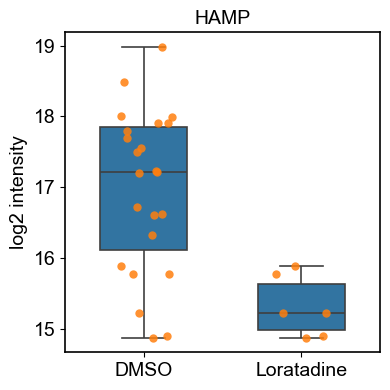

In [71]:
plot_box_strip_by_gene(
    df=df_raw,
    gene_name="HAMP",
    figsize=(4, 4),
    drugs=["DMSO", "Loratadine"],
    gene_col="gene",
    ylabel="log2 intensity",
    save_path=file_path_manual
)

Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\HMGCR.svg


C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


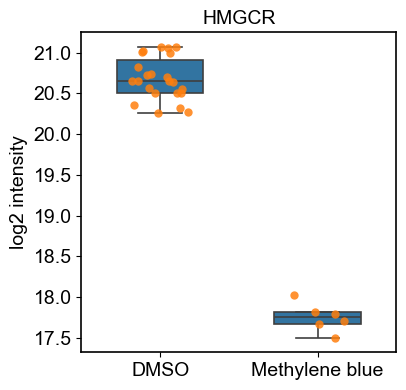

In [72]:
plot_box_strip_by_gene(
    df=df_raw,
    gene_name="HMGCR",
    figsize=(4, 4),
    drugs=["DMSO", "Methylene blue (trihydrate)"],
    gene_col="gene",
    ylabel="log2 intensity",
    save_path=file_path_manual
)

Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\SQLE.svg


C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


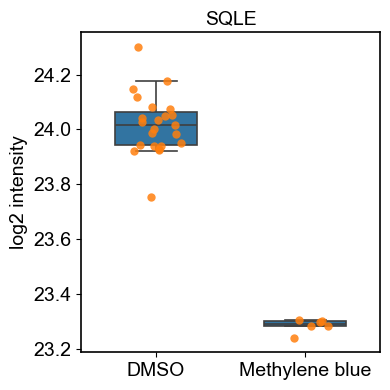

In [73]:
plot_box_strip_by_gene(
    df=df_raw,
    gene_name="SQLE",
    figsize=(4, 4),
    drugs=["DMSO", "Methylene blue (trihydrate)"],
    gene_col="gene",
    ylabel="log2 intensity",
    save_path=file_path_manual
)

Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\FDFT1.svg


C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


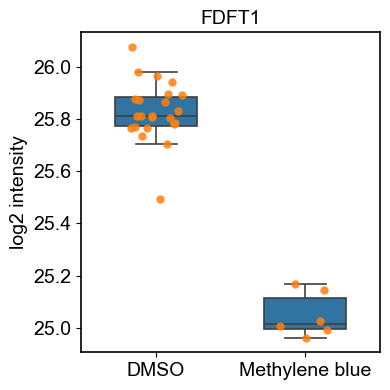

In [74]:
plot_box_strip_by_gene(
    df=df_raw,
    gene_name="FDFT1",
    figsize=(4, 4),
    drugs=["DMSO", "Methylene blue (trihydrate)"],
    gene_col="gene",
    ylabel="log2 intensity",
    save_path=file_path_manual
)

Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\SCD.svg


C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


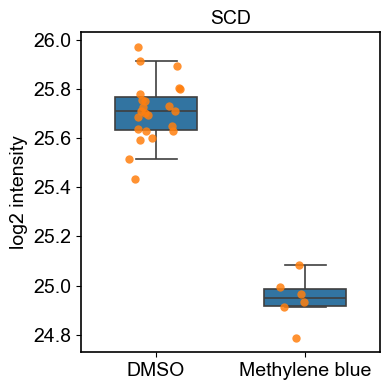

In [75]:
plot_box_strip_by_gene(
    df=df_raw,
    gene_name="SCD",
    figsize=(4, 4),
    drugs=["DMSO", "Methylene blue (trihydrate)"],
    gene_col="gene",
    ylabel="log2 intensity",
    save_path=file_path_manual
)

In [76]:
file_path_manual2 = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\genevsdmso"

Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\genevsdmso\simvastatin\SQLE.svg


C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


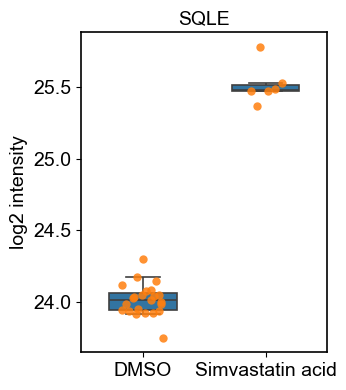

C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\genevsdmso\simvastatin\FDFT1.svg


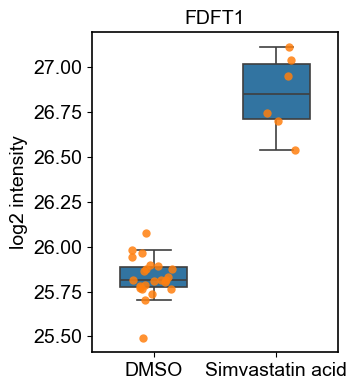

Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\genevsdmso\simvastatin\MSMO1.svg


C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


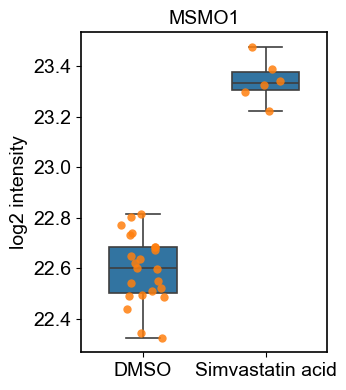

C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\genevsdmso\simvastatin\SCD.svg


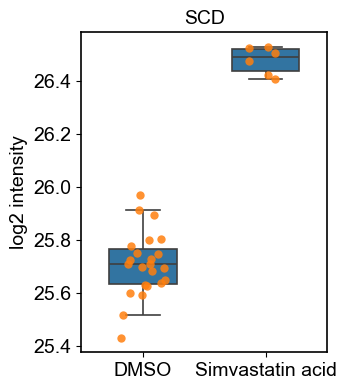

C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\genevsdmso\simvastatin\LDLR.svg


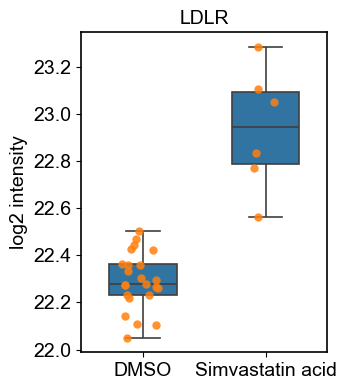

C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\2590309724.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=0, ha="center", fontsize=14)


Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\genevsdmso\simvastatin\HMGCR.svg


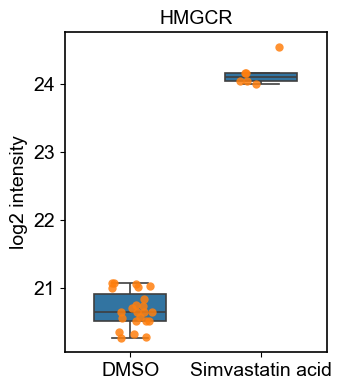

In [98]:
file_path_manual2 = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\genevsdmso\simvastatin"

listx = ["SQLE", "FDFT1", "MSMO1", "SCD", "LDLR", "HMGCR"]

for genename in listx:
    

    plot_box_strip_by_gene(
        df=df_raw,
        gene_name=genename,
        figsize=(3.5, 4),
        drugs=["DMSO", "Simvastatin acid (ammonium)"],
        gene_col="gene",
        ylabel="log2 intensity",
        save_path=file_path_manual2
    )

# heatmap plot

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler

def plot_fcm_cluster_heatmap(
    nes_matrix,
    membership_df,
    top_n_terms_per_cluster=5,
    scale_by_term=True,
    figsize=(12, 16),
    cmap="vlag",
    vmin=-2.5,
    vmax=2.5,
    cluster_order=None,
    show_term_labels=True,
    show_drug_labels=False,
    save_path=None
):
    """
    Plot heatmap for FCM clustering result.

    Parameters
    ----------
    nes_matrix : pd.DataFrame
        drug × term matrix
    membership_df : pd.DataFrame
        Must contain columns: ['main_cluster', 'max_membership']
    top_n_terms_per_cluster : int
        Select top up and top down terms per cluster
    scale_by_term : bool
        Whether to z-score each term (column-wise)
    figsize : tuple
        Figure size
    cmap : str
        Heatmap colormap
    vmin, vmax : float
        Heatmap color range
    cluster_order : list or None
        Custom order of clusters, e.g. ['cluster_1', 'cluster_2', ...]
    show_term_labels : bool
    show_drug_labels : bool
    save_path : str or None
    """

    # --------------------------
    # 1. align drugs
    # --------------------------
    common_drugs = nes_matrix.index.intersection(membership_df.index)
    mat = nes_matrix.loc[common_drugs].copy()
    meta = membership_df.loc[common_drugs].copy()

    if "main_cluster" not in meta.columns:
        raise ValueError("membership_df must contain 'main_cluster'")
    if "max_membership" not in meta.columns:
        raise ValueError("membership_df must contain 'max_membership'")

    # --------------------------
    # 2. cluster profile
    # --------------------------
    cluster_profile = (
        mat.join(meta["main_cluster"])
        .groupby("main_cluster")
        .mean()
    )

    # cluster order
    if cluster_order is None:
        cluster_order = cluster_profile.index.tolist()

    cluster_profile = cluster_profile.loc[cluster_order]

    # --------------------------
    # 3. select representative terms
    #    each cluster: top up + top down
    # --------------------------
    selected_terms = []

    for cl in cluster_order:
        s = cluster_profile.loc[cl].sort_values(ascending=False)
        top_up = s.head(top_n_terms_per_cluster).index.tolist()
        top_down = s.tail(top_n_terms_per_cluster).index.tolist()
        selected_terms.extend(top_up + top_down)

    selected_terms = list(dict.fromkeys(selected_terms))  # remove duplicates, keep order
    mat = mat[selected_terms].copy()

    # --------------------------
    # 4. scale matrix by term
    # --------------------------
    if scale_by_term:
        scaler = StandardScaler()
        mat_plot = pd.DataFrame(
            scaler.fit_transform(mat),
            index=mat.index,
            columns=mat.columns
        )
    else:
        mat_plot = mat.copy()

    # --------------------------
    # 5. row order: cluster first, then membership strength
    # --------------------------
    meta["main_cluster"] = pd.Categorical(meta["main_cluster"], categories=cluster_order, ordered=True)
    order_df = meta.sort_values(["main_cluster", "max_membership"], ascending=[True, False])

    mat_plot = mat_plot.loc[order_df.index]
    meta = meta.loc[order_df.index]

    # --------------------------
    # 6. prepare row annotation colors
    # --------------------------
    unique_clusters = cluster_order
    palette = sns.color_palette("tab10", n_colors=len(unique_clusters))
    cluster_to_color = {cl: palette[i] for i, cl in enumerate(unique_clusters)}
    row_colors = np.array([cluster_to_color[c] for c in meta["main_cluster"]])

    # --------------------------
    # 7. compute cluster boundaries
    # --------------------------
    cluster_sizes = meta["main_cluster"].value_counts().loc[cluster_order]
    boundaries = np.cumsum(cluster_sizes.values)

    # --------------------------
    # 8. plot
    # --------------------------
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 2, width_ratios=[40, 1.5], wspace=0.02)

    ax = fig.add_subplot(gs[0, 0])
    ax_ann = fig.add_subplot(gs[0, 1])

    sns.heatmap(
        mat_plot,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        xticklabels=show_term_labels,
        yticklabels=show_drug_labels,
        rasterized=True
    )

    # horizontal lines between clusters
    for b in boundaries[:-1]:
        ax.hlines(b, *ax.get_xlim(), colors="white", linewidth=2)

    # main heatmap formatting
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=9, rotation=60)
    ax.tick_params(axis="y", labelsize=6)

    # right-side cluster bar
    ann_matrix = np.arange(len(meta)).reshape(-1, 1)
    ann_color_idx = np.array([unique_clusters.index(c) for c in meta["main_cluster"]]).reshape(-1, 1)

    ax_ann.imshow(
        ann_color_idx,
        aspect="auto",
        cmap=ListedColormap(palette),
        interpolation="nearest"
    )
    ax_ann.set_xticks([])
    ax_ann.set_yticks([])

    # cluster labels on right
    start = 0
    for i, cl in enumerate(cluster_order):
        size = cluster_sizes.loc[cl]
        y = start + size / 2
        ax_ann.text(
            0.5, y,
            str(cl).replace("_", " "),
            ha="center", va="center",
            fontsize=9, color="white", rotation=270,
            transform=ax_ann.transData
        )
        start += size

    for b in boundaries[:-1]:
        ax_ann.hlines(b - 0.5, -0.5, 0.5, colors="white", linewidth=2)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

    return {
        "selected_terms": selected_terms,
        "cluster_profile": cluster_profile,
        "ordered_matrix": mat_plot,
        "ordered_meta": meta
    }

C:\Users\jymbc\AppData\Local\Temp\ipykernel_57500\1269876500.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


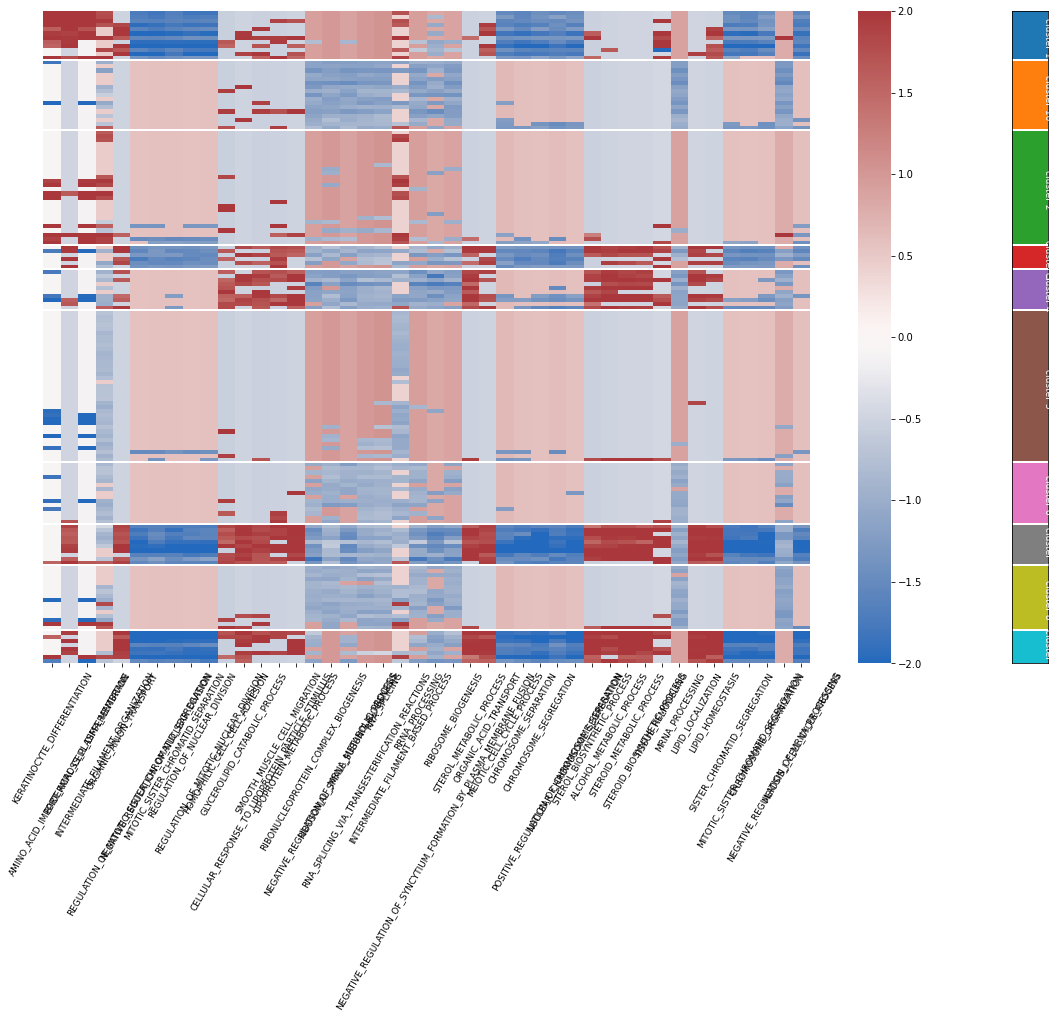

In [113]:
heatmap_result = plot_fcm_cluster_heatmap(
    nes_matrix=result["nes_matrix"],
    membership_df=result["membership"],
    top_n_terms_per_cluster=5,
    scale_by_term=True,
    figsize=(18, 12),
    cmap="vlag",
    vmin=-2,
    vmax=2,
    show_term_labels=True,
    show_drug_labels=False,
    # save_path="fcm_go_heatmap.png"
)

# heatmap version 3

In [153]:
def plot_fcm_heatmap_version3(
    nes_matrix,
    membership_df,
    cluster_profile=None,
    top_up_per_cluster=2,
    top_down_per_cluster=2,
    extra_global_terms=8,
    custom_extra_terms=None,
    scale_by_term=True,
    figsize=(24, 14),
    cmap="vlag",
    vmin=-2.5,
    vmax=2.5,
    cluster_order=None,
    show_drug_labels=False,
    save_path=None
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.colors import ListedColormap
    from matplotlib.gridspec import GridSpec
    from sklearn.preprocessing import StandardScaler

    # --------------------------
    # 1. align
    # --------------------------
    common = nes_matrix.index.intersection(membership_df.index)
    mat = nes_matrix.loc[common].copy()
    meta = membership_df.loc[common].copy()

    # --------------------------
    # 2. cluster profile
    # --------------------------
    if cluster_profile is None:
        cluster_profile = (
            mat.join(meta["main_cluster"])
            .groupby("main_cluster")
            .mean()
        )

    if cluster_order is None:
        cluster_order = cluster_profile.index.tolist()

    # --------------------------
    # 3. row order
    # --------------------------
    meta["main_cluster"] = pd.Categorical(
        meta["main_cluster"],
        categories=cluster_order,
        ordered=True
    )
    meta = meta.sort_values(["main_cluster", "max_membership"], ascending=[True, False])
    mat = mat.loc[meta.index]

    # --------------------------
    # 4. column order
    # --------------------------
    cp = cluster_profile.loc[cluster_order, mat.columns]

    peak_cluster = cp.idxmax(axis=0)
    spread = cp.max(axis=0) - cp.min(axis=0)

    col_meta = pd.DataFrame({
        "term": mat.columns,
        "peak_cluster": peak_cluster.values,
        "spread": spread.values
    }).set_index("term")

    col_meta["peak_cluster"] = pd.Categorical(
        col_meta["peak_cluster"],
        categories=cluster_order,
        ordered=True
    )

    col_meta = col_meta.sort_values(["peak_cluster", "spread"], ascending=[True, False])
    mat = mat[col_meta.index]

    # --------------------------
    # 5. scale
    # --------------------------
    if scale_by_term:
        scaler = StandardScaler()
        mat_plot = pd.DataFrame(
            scaler.fit_transform(mat),
            index=mat.index,
            columns=mat.columns
        )
    else:
        mat_plot = mat.copy()

    # --------------------------
    # 6. label terms
    # --------------------------
    label_terms = []

    for cl in cluster_order:
        s = cp.loc[cl].sort_values(ascending=False)
        top_up = s.head(top_up_per_cluster).index.tolist()
        top_down = s.tail(top_down_per_cluster).index.tolist()
        label_terms.extend(top_up + top_down)

    label_terms = list(dict.fromkeys(label_terms))

    # 先加自定义 extra terms
    if custom_extra_terms is not None:
        custom_extra = [
            t for t in custom_extra_terms
            if t in mat_plot.columns and t not in label_terms
        ]
        label_terms.extend(custom_extra)

    # 再加自动筛选的 global terms
    if extra_global_terms > 0:
        specificity = (cp.max(axis=0) - cp.min(axis=0)).sort_values(ascending=False)
        extra = [t for t in specificity.index if t not in label_terms][:extra_global_terms]
        label_terms.extend(extra)

    xtick_pos = [i for i, t in enumerate(mat_plot.columns) if t in label_terms]
    xtick_labels = [t for t in mat_plot.columns if t in label_terms]

    # --------------------------
    # 7. cluster boundaries
    # --------------------------
    cluster_sizes = meta["main_cluster"].value_counts().reindex(cluster_order)
    boundaries = np.cumsum(cluster_sizes.values)

    # --------------------------
    # 8. plot
    # --------------------------
    fig = plt.figure(figsize=figsize)

    gs = GridSpec(1, 2, width_ratios=[45, 0.8], wspace=0.005)

    ax = fig.add_subplot(gs[0, 0])
    ax_ann = fig.add_subplot(gs[0, 1])

    hm = sns.heatmap(
        mat_plot,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        xticklabels=False,
        yticklabels=show_drug_labels,
        cbar=True,
        cbar_kws={
            "shrink": 0.18,
            "aspect": 8
        },
        cbar_ax=fig.add_axes([0.087, 0.72, 0.012, 0.15]),
        rasterized=True
    )

    ax.set_xticks(np.array(xtick_pos) + 0.5)
    ax.set_xticklabels(
        xtick_labels,
        rotation=30,
        ha="right",
        fontsize=13,
        rotation_mode="anchor"
    )

    for b in boundaries[:-1]:
        ax.hlines(b, *ax.get_xlim(), colors="white", linewidth=4)

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=6, length=0)
    ax.tick_params(axis="x", length=0)

    # --------------------------
    # 9. style colorbar
    # --------------------------
    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13, length=2)
    cbar.set_label("color scale", fontsize=13)

    # --------------------------
    # 10. right annotation bar
    # --------------------------
    palette = sns.color_palette("tab10", len(cluster_order))
    idx = np.array([cluster_order.index(c) for c in meta["main_cluster"]]).reshape(-1, 1)

    ax_ann.imshow(idx, aspect="auto", cmap=ListedColormap(palette), interpolation="nearest")
    ax_ann.set_xticks([])
    ax_ann.set_yticks([])

    for spine in ax_ann.spines.values():
        spine.set_visible(False)

    start = 0
    for cl in cluster_order:
        size = cluster_sizes.loc[cl]
        y = start + size / 2
        ax_ann.text(
            0.05, y,
            str(cl).replace("cluster_", ""),
            ha="center", va="center",
            fontsize=14, color="black", rotation=90
        )
        start += size

    for b in boundaries[:-1]:
        ax_ann.hlines(b - 0.5, -0.5, 0.5, colors="white", linewidth=6)

    plt.tight_layout(rect=[0.09, 0, 1, 1])

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

    return {
        "label_terms": label_terms,
        "cluster_profile": cp,
        "ordered_matrix": mat_plot
    }

In [156]:
nes_matrix_go = drug_clustering_go_fcm_matrix.copy()

nes_matrix_go  = nes_matrix_go.iloc[:, [0] + list(range(8, nes_matrix_go.shape[1]))]
nes_matrix_go.set_index("drug", inplace = True)
nes_matrix_go

,INTERMEDIATE_FILAMENT_ORGANIZATION,INTERMEDIATE_FILAMENT_BASED_PROCESS,KERATINOCYTE_DIFFERENTIATION,RNA_SPLICING,RIBOSOMAL_SMALL_SUBUNIT_BIOGENESIS,RRNA_PROCESSING,RNA_SPLICING_VIA_TRANSESTERIFICATION_REACTIONS,RIBONUCLEOPROTEIN_COMPLEX_BIOGENESIS,RIBOSOME_BIOGENESIS,MATURATION_OF_SSU_RRNA,...,NEGATIVE_REGULATION_OF_CELL_CYCLE_G2_M_PHASE_TRANSITION,PROTEIN_CATABOLIC_PROCESS_IN_THE_VACUOLE,REGULATION_OF_CELL_DIVISION,PROTEIN_RNA_COMPLEX_ORGANIZATION,REGULATION_OF_DNA_TEMPLATED_DNA_REPLICATION,CENTRIOLE_ASSEMBLY,MATURATION_OF_SSU_RRNA_FROM_TRICISTRONIC_RRNA_TRANSCRIPT_SSU_RRNA_5_8S_RRNA_LSU_RRNA,ISOPRENOID_BIOSYNTHETIC_PROCESS,NEURON_PROJECTION_GUIDANCE,POSITIVE_REGULATION_OF_MITOTIC_NUCLEAR_DIVISION
drug,,,,,,,,,,,,,,,,,,,,,
6-Mercaptopurine,0.000000,0.000000,1.807077,0.000000,-1.874859,-1.730007,0.000000,-1.760954,-1.935513,-1.739768,...,0.000000,0.00000,-1.725892,0.000000,-1.783409,-1.919639,0.000000,0.000000,1.820281,-1.863857
ATP (dimagnesium),-1.810522,0.000000,0.000000,0.000000,0.000000,-1.854691,0.000000,-1.895123,-1.909979,-1.822942,...,0.000000,0.00000,0.000000,0.000000,-1.895197,0.000000,0.000000,0.000000,0.000000,0.000000
Abemaciclib (methanesulfonate),0.000000,0.000000,1.797888,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.678335,0.00000,-1.637027,0.000000,-1.863315,-1.651100,0.000000,0.000000,0.000000,-1.589931
Acetophenazine (dimaleate),-2.444746,-2.614464,-2.275356,-2.092508,-2.295920,-2.273547,-2.036551,-2.127150,-2.046297,-2.269147,...,0.000000,1.79848,0.000000,-1.842546,0.000000,0.000000,-1.741255,1.814091,1.946372,0.000000
Adiphenine (hydrochloride),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Varenicline (Hydrochloride),-2.486422,-2.311460,0.000000,-2.002691,0.000000,0.000000,-2.017334,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Vasopressin,-2.397502,-2.234492,0.000000,-1.987142,0.000000,0.000000,-1.940299,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Vemurafenib,-2.160315,-1.979381,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [160]:
result["nes_matrix"]

Term,INTERMEDIATE_FILAMENT_ORGANIZATION,INTERMEDIATE_FILAMENT_BASED_PROCESS,KERATINOCYTE_DIFFERENTIATION,RNA_SPLICING,RIBOSOMAL_SMALL_SUBUNIT_BIOGENESIS,RRNA_PROCESSING,RNA_SPLICING_VIA_TRANSESTERIFICATION_REACTIONS,RIBONUCLEOPROTEIN_COMPLEX_BIOGENESIS,RIBOSOME_BIOGENESIS,MATURATION_OF_SSU_RRNA,...,NEGATIVE_REGULATION_OF_CELL_CYCLE_G2_M_PHASE_TRANSITION,PROTEIN_CATABOLIC_PROCESS_IN_THE_VACUOLE,REGULATION_OF_CELL_DIVISION,PROTEIN_RNA_COMPLEX_ORGANIZATION,REGULATION_OF_DNA_TEMPLATED_DNA_REPLICATION,CENTRIOLE_ASSEMBLY,MATURATION_OF_SSU_RRNA_FROM_TRICISTRONIC_RRNA_TRANSCRIPT_SSU_RRNA_5_8S_RRNA_LSU_RRNA,ISOPRENOID_BIOSYNTHETIC_PROCESS,NEURON_PROJECTION_GUIDANCE,POSITIVE_REGULATION_OF_MITOTIC_NUCLEAR_DIVISION
drug,,,,,,,,,,,,,,,,,,,,,
6-Mercaptopurine,0.000000,0.000000,1.807077,0.000000,-1.874859,-1.730007,0.000000,-1.760954,-1.935513,-1.739768,...,0.000000,0.00000,-1.725892,0.000000,-1.783409,-1.919639,0.000000,0.000000,1.820281,-1.863857
ATP (dimagnesium),-1.810522,0.000000,0.000000,0.000000,0.000000,-1.854691,0.000000,-1.895123,-1.909979,-1.822942,...,0.000000,0.00000,0.000000,0.000000,-1.895197,0.000000,0.000000,0.000000,0.000000,0.000000
Abemaciclib (methanesulfonate),0.000000,0.000000,1.797888,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.678335,0.00000,-1.637027,0.000000,-1.863315,-1.651100,0.000000,0.000000,0.000000,-1.589931
Acetophenazine (dimaleate),-2.444746,-2.614464,-2.275356,-2.092508,-2.295920,-2.273547,-2.036551,-2.127150,-2.046297,-2.269147,...,0.000000,1.79848,0.000000,-1.842546,0.000000,0.000000,-1.741255,1.814091,1.946372,0.000000
Adiphenine (hydrochloride),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Varenicline (Hydrochloride),-2.486422,-2.311460,0.000000,-2.002691,0.000000,0.000000,-2.017334,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Vasopressin,-2.397502,-2.234492,0.000000,-1.987142,0.000000,0.000000,-1.940299,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Vemurafenib,-2.160315,-1.979381,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [162]:
ji = drug_clustering_go_fcm_membership.set_index("drug").copy()
ji

,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10,main_cluster,max_membership,membership_entropy,cluster_num,cluster,membership_score,display_label,target,pathway,research_area
drug,,,,,,,,,,,,,,,,,,,,
6-Mercaptopurine,0.465420,0.037318,0.136738,0.040778,0.036918,0.035636,0.064769,0.039371,0.074885,0.068167,cluster_1,0.465420,1.803623,1,Cluster_1,0.465420,6-Mercaptopurine,Autophagy; Endogenous Metabolite; Nucleoside A...,Autophagy; Cell Cycle/DNA Damage; Metabolic En...,Cancer
ATP (dimagnesium),0.001674,0.138089,0.001195,0.003292,0.429627,0.026126,0.000577,0.367270,0.000875,0.031276,cluster_5,0.429627,1.255856,5,Cluster_5,0.429627,ATP (dimagnesium),Endogenous Metabolite,Metabolic Enzyme/Protease,Inflammation/Immunology
Abemaciclib (methanesulfonate),0.715480,0.023161,0.059602,0.022287,0.025179,0.021190,0.030076,0.026007,0.030339,0.046680,cluster_1,0.715480,1.203370,1,Cluster_1,0.715480,Abemaciclib (methanesulfonate),CDK,Cell Cycle/DNA Damage,Cancer
Acetophenazine (dimaleate),0.025692,0.042158,0.039043,0.526033,0.033800,0.054138,0.046373,0.040781,0.123119,0.068862,cluster_4,0.526033,1.679499,4,Cluster_4,0.526033,Acetophenazine (dimaleate),Dopamine Receptor,GPCR/G Protein; Neuronal Signaling,Neurological Disease
Adiphenine (hydrochloride),0.000522,0.016987,0.000359,0.000973,0.896311,0.005451,0.000176,0.070017,0.000263,0.008941,cluster_5,0.896311,0.441337,5,Cluster_5,0.896311,Adiphenine (hydrochloride),nAChR,Membrane Transporter/Ion Channel; Neuronal Sig...,Neurological Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Varenicline (Hydrochloride),0.000899,0.086376,0.000637,0.001911,0.239810,0.016018,0.000321,0.636570,0.000491,0.016967,cluster_8,0.636570,1.006142,8,Cluster_8,0.636570,Varenicline (Hydrochloride),nAChR,Membrane Transporter/Ion Channel; Neuronal Sig...,Neurological Disease; Cancer
Vasopressin,0.001296,0.120147,0.000926,0.002930,0.182639,0.025230,0.000472,0.640852,0.000729,0.024778,cluster_8,0.640852,1.075799,8,Cluster_8,0.640852,Vasopressin,Endogenous Metabolite,Metabolic Enzyme/Protease,Neurological Disease
Vemurafenib,0.071192,0.105375,0.033657,0.072250,0.131883,0.085165,0.020364,0.135336,0.033113,0.311665,cluster_10,0.311665,2.032337,10,Cluster_10,0.311665,Vemurafenib,Autophagy; Raf,Autophagy; MAPK/ERK Pathway,Cancer


C:\Users\jymbc\AppData\Local\Temp\ipykernel_30712\574034331.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.09, 0, 1, 1])


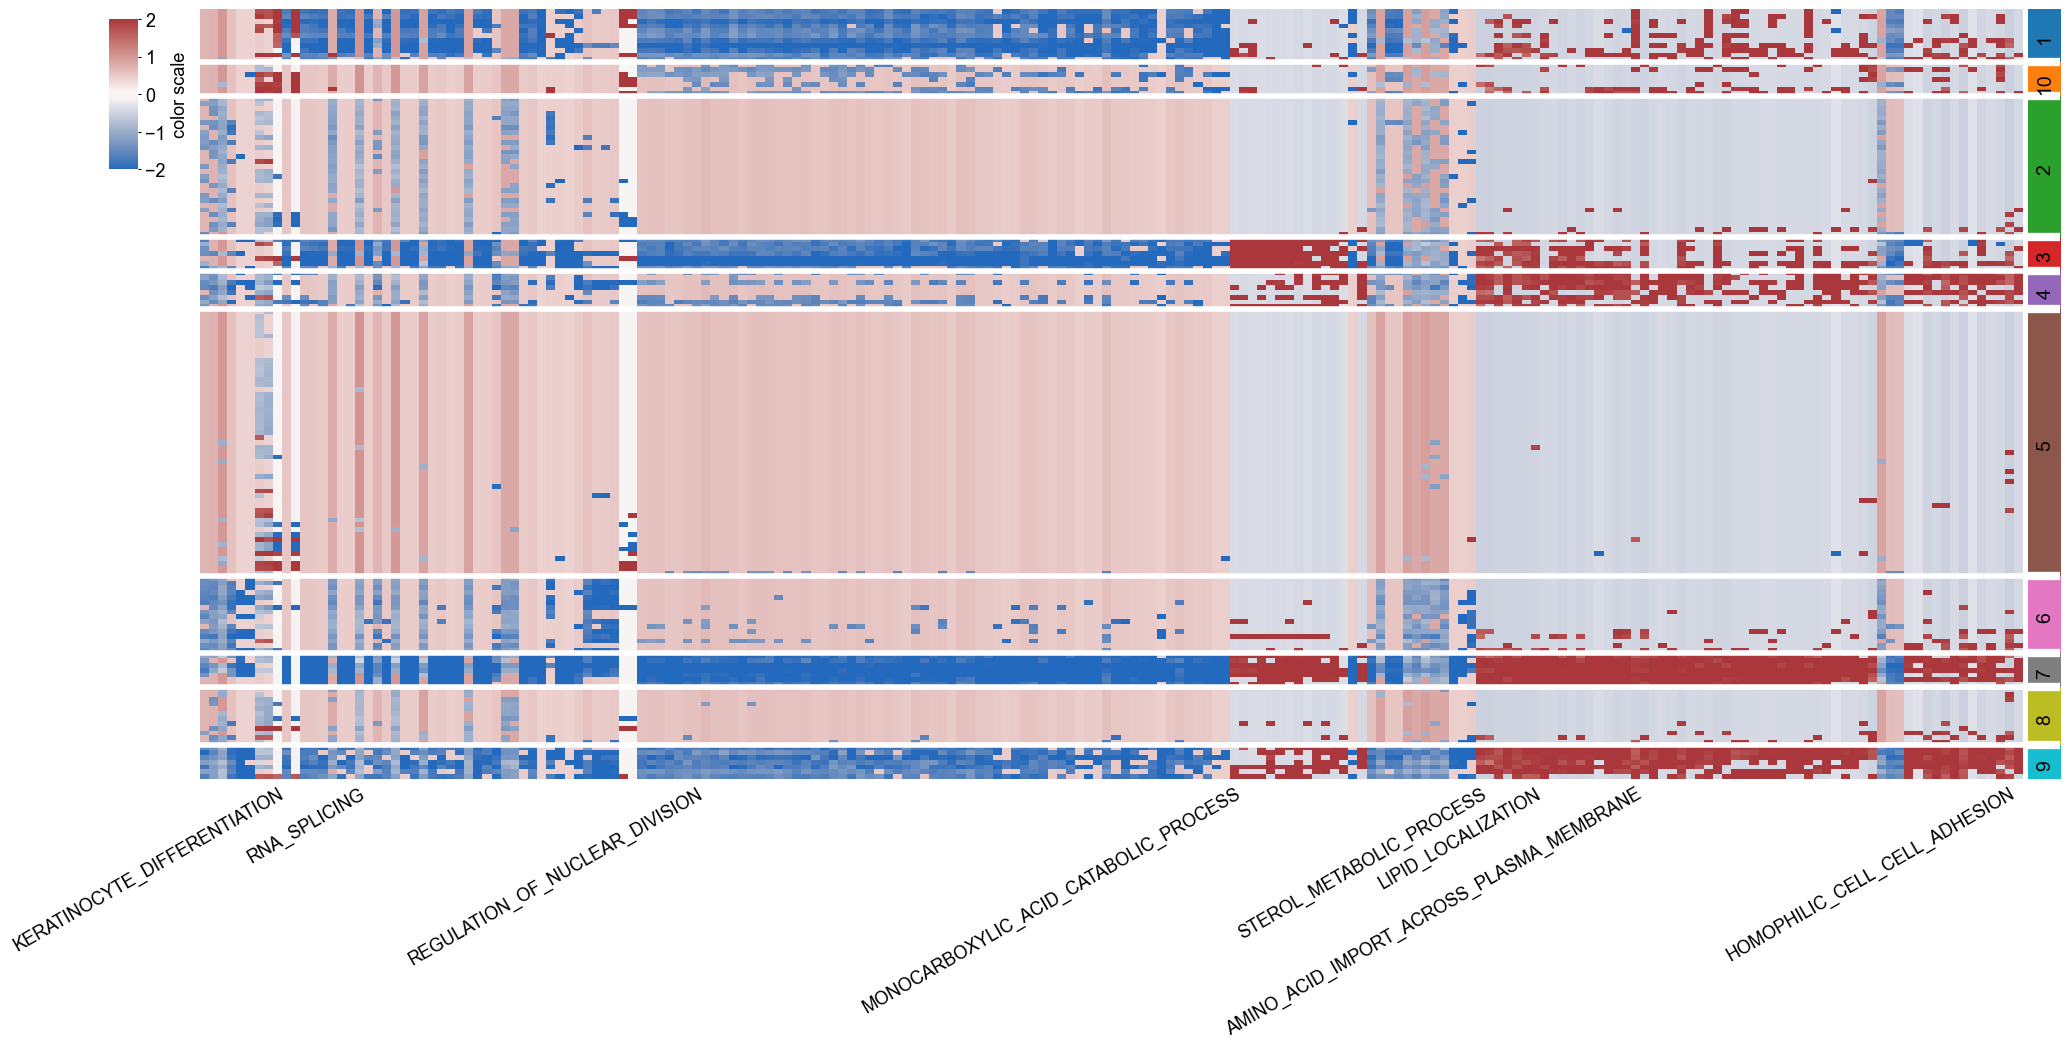

In [163]:
figure_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\figures"

heatmap_res = plot_fcm_heatmap_version3(
    nes_matrix=result["nes_matrix"],
    membership_df=ji,
    top_up_per_cluster=1,
    top_down_per_cluster=0,
    extra_global_terms=0,
    custom_extra_terms=[
        "RNA_SPLICING",
        "LIPID_LOCALIZATION",
        "REGULATION_OF_NUCLEAR_DIVISION",
    ],
    figsize=(24, 10),
    cmap="vlag",
    vmin=-2,
    vmax=2,
    scale_by_term=True,
    show_drug_labels=False,
    save_path=f"{figure_path}/GO_clustering_heatmap_new.svg"
)

In [6]:

nes_mat_go = gsea_df_go.pivot_table(
    index="Term",
    columns="drug",
    values="NES",
    aggfunc="mean"
)

fdr_mat_go = gsea_df_go.pivot_table(
    index="Term",
    columns="drug",
    values="FDR",
    aggfunc="mean"
)

print(nes_mat_go.shape)
display(nes_mat_go.head())

(2296, 170)


drug,6-Mercaptopurine,ATP (dimagnesium),Abemaciclib (methanesulfonate),Acetophenazine (dimaleate),Adiphenine (hydrochloride),Alcaftadine,Alizapride (hydrochloride),Almotriptan (malate),Ambroxol,Amcinonide,...,Umbralisib,Vadadustat,Vardenafil,Varenicline (Hydrochloride),Vasopressin,Vecuronium (bromide),Vemurafenib,Zanubrutinib,Î±-Lipoic Acid,Î³-Oryzanol
Term,,,,,,,,,,,,,,,,,,,,,
ACETYL_COA_BIOSYNTHETIC_PROCESS,1.048749,0.809119,-1.119894,1.172638,-0.891750,0.937201,0.600267,0.574024,1.200304,0.607116,...,1.046418,1.294219,0.514420,0.648744,-1.091877,-0.886659,-0.741446,1.052911,1.022761,0.610163
ACETYL_COA_METABOLIC_PROCESS,-1.028867,0.870601,-0.678223,1.396347,-1.118607,0.602872,-0.728414,0.594885,1.174868,-0.683876,...,1.591529,1.410503,-0.777840,0.480093,-1.006656,0.764545,-1.297847,1.548008,1.019081,-0.625777
ACIDIC_AMINO_ACID_TRANSPORT,1.803196,-0.847215,1.555083,1.641527,-0.831775,0.817240,0.795418,0.880720,0.769217,-0.829880,...,0.948551,0.650764,0.979981,0.744295,0.787084,1.137109,1.749507,-0.704053,1.319124,0.766091
ACTIN_FILAMENT_BASED_MOVEMENT,1.479806,0.830345,-0.519094,-0.616525,-1.471161,-0.307535,-0.409035,-0.813588,-0.903958,-0.483940,...,-0.970465,0.790925,-1.180592,-0.721162,0.609112,-1.180952,-0.784691,-1.339676,-0.777084,-0.875754
ACTIN_FILAMENT_BASED_PROCESS,1.212732,1.328543,-0.621434,0.781429,-0.763410,0.958205,-0.761456,-0.712038,0.776833,0.973267,...,-1.125536,1.440096,0.689777,1.055800,0.879188,0.742062,1.087172,-1.359824,-1.174688,-0.814557
